# OREGANO: From ontology construction to Bayesian candidate ranking

**Ibrahim Ineizeh**

Combined knowledge engineering study · original analysis: 2025 · editorial packaging: 2026

I first built an ontology from OREGANO and explored how its entities connect. I then used those connections to search for missing treatment links and construct a Bayesian model for ranking compounds against selected disease nodes. This notebook brings both stages together so that the construction, decisions, findings and limitations can be read in one sequence.

**Reading the results.** Every stored code output below comes from the original assessment notebooks. I have retained those outputs as a historical record; they have **not been regenerated after the portability, ordering and display changes**. Original category indices and execution counts therefore describe the saved run. A new run can produce different indices and rankings. The sampled counts are model outputs, not probabilities that a drug will treat a disease.

The accompanying [report](../report.md) presents the findings and figures. [Notebook changes](../docs/notebook-changes.md) records the editorial corrections and the practical limits of reproduction.

**Contents**

- Setup and data paths
- Stage 1: Constructing and exploring the ontology
- Stage 2: Indirect paths and Bayesian candidate ranking
- Reflections, AI disclosure and references

![Workflow from ontology construction to candidate inspection](../figures/workflow.png)


## Setup and data paths

I use the package root as the working reference, so the notebook can run from the root directory or its `notebooks` directory. Place the original OREGANO entity tables and `OREGANO_V2.1.tsv` in `data/`, as described in the package documentation. The construction stage writes `data/oregano.owl`; generated HTML graphs go to `visualizations/generated/`.

This is the full original analysis, including large arrays and long sampling runs. The protein conditional tensor alone occupied about 807 MB in the saved run. Each disease sampling call requests one million draws per chain. Reading the retained tables and plots does not require running the notebook.


In [ ]:
from pathlib import Path

_working_dir = Path.cwd().resolve()
ROOT = next(
    (
        candidate
        for candidate in (_working_dir, _working_dir.parent)
        if (candidate / "notebooks" / "oregano-study.ipynb").is_file()
        and (candidate / "scripts").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the study package. Open this notebook from the package "
        "root or its notebooks directory."
    )

DATA_DIR = ROOT / "data"
OWL_PATH = DATA_DIR / "oregano.owl"
OUTPUT_DIR = ROOT / "visualizations" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Historical fixed seed; retained to explain the original runs.
SEED = 40490625

from owlready2 import *
import pandas as pd
import numpy as np
from pyvis.network import Network
from tqdm.notebook import tqdm
import pymc as mc
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import HTML
import random

# An isolated world avoids mixing this study with a previous notebook run.
world = World()

def show_graph(network, filename):
    # Save a portable HTML graph and display its embedded resources.
    output_path = OUTPUT_DIR / filename
    network.write_html(str(output_path), notebook=True, open_browser=False)
    return HTML(filename=str(output_path))


## Stage 1: Constructing and exploring the ontology


Drug repurposing investigates whether an existing compound has useful connections to another disease. I used OREGANO, a knowledge graph developed for computational drug repurposing [1], to explore those connections. I first converted the tabular entities and relations into an OWL ontology, then used queries and visualizations to inspect its structure.


The original target table contains both proteins and molecules. I separated these into two entity classes because their connections differ. I also kept `has_code` as compound information rather than an object relation, since it does not link two entity records in these input tables.


### Loading the tables and constructing the ontology


I normalized column names and entity identifiers so they could be used in the OWL file. Missing table values were stored as zero in the original implementation. That convention is retained here and should be treated as missing information, rather than a measured biological value.


In [3]:
#This function checks the name and fixes them to be compatible with XML formatting 
import re
def fix_name(s):
    s = re.sub('[^0-9a-zA-Z]+', '_', s)
    if re.match('^[0-9]',s):
        s = f"X{s}"
    return s

In [4]:
required_tables = [
    "ACTIVITY", "COMPOUND", "DISEASES", "EFFECT", "GENES",
    "INDICATION", "PATHWAYS", "PHENOTYPES", "SIDE_EFFECT", "TARGET",
]
required_paths = [DATA_DIR / f"{name}.tsv" for name in required_tables]
required_paths.append(DATA_DIR / "OREGANO_V2.1.tsv")
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        "OREGANO input tables are missing: "
        + ", ".join(str(path) for path in missing_paths)
        + ". Place the original release tables in the package data directory."
    )
world = World()

# List the entities in the ontology 
entity_list = ['ACTIVITY','COMPOUND','DISEASES','EFFECT','GENES', 'INDICATION', 'PATHWAYS', 'PHENOTYPES', 'SIDE_EFFECT', 'TARGET']
# Create a dummy ontology since one wasn't provided 
onto = world.get_ontology("http://www.dummy.info/new.owl")

# A dictionary to store in the entities 
entities = dict()
for entity in entity_list:
        with open(DATA_DIR / f"{entity}.tsv", encoding="utf-8") as csvfile:
            temp_dataframe = pd.read_csv(csvfile, sep='\t', low_memory=False)
            for name in temp_dataframe.columns:
                # fix all the columns names by using the fix_name function
                temp_dataframe.rename(columns={name: fix_name(name)}, inplace=True)
            for i, row in temp_dataframe.iterrows():
                # fix each row name 
                id_column = temp_dataframe.columns[0]
                name = row[id_column]
                new_name = fix_name(name)
                temp_dataframe.at[i, id_column] = new_name
            # fill any missing value with a 0 
            temp_dataframe.fillna(0, inplace=True)
            if entity == 'TARGET':
                # special cause for the target 
                # create two masks for both the protein and molecule 
                protein_mask = temp_dataframe.iloc[:, 0].str.startswith('PROTEIN')
                molecule_mask = temp_dataframe.iloc[:, 0].str.startswith('MOLECULE')
                entities['PROTEIN'] = temp_dataframe[protein_mask]
                entities['MOLECULE'] = temp_dataframe[molecule_mask]
                print('Success Loading data of type PROTEIN')
                print('Success Loading data of type MOLECULE')
            else:
                # for the rest of the entities
                entities[entity] = temp_dataframe
                print(f'Success Loading data of type {entity}')

# print the total number of entities 
print(f'The total number of entities: {len(entities)}')

Success Loading data of type ACTIVITY
Success Loading data of type COMPOUND
Success Loading data of type DISEASES
Success Loading data of type EFFECT
Success Loading data of type GENES
Success Loading data of type INDICATION
Success Loading data of type PATHWAYS
Success Loading data of type PHENOTYPES
Success Loading data of type SIDE_EFFECT
Success Loading data of type PROTEIN
Success Loading data of type MOLECULE
The total number of entities: 11


In [5]:
# Craete the classes for each entity with Thing as thier base class 
with onto:
    EntityClasses = dict()
    for entity in entities.keys():
        EntityClasses[entity] = type(entity, (Thing,), dict())
        print(f'Created entity class {EntityClasses[entity]}')

Created entity class new.ACTIVITY
Created entity class new.COMPOUND
Created entity class new.DISEASES
Created entity class new.EFFECT
Created entity class new.GENES
Created entity class new.INDICATION
Created entity class new.PATHWAYS
Created entity class new.PHENOTYPES
Created entity class new.SIDE_EFFECT
Created entity class new.PROTEIN
Created entity class new.MOLECULE


In [6]:
# Create attributes for each type 
with onto:
    attributes = dict()
    for entity in entities.keys():
        attribute_names = list(entities[entity])
        for a in attribute_names[1:]:
                if a not in attributes.keys():
                    attributes[a] = {'domain': [EntityClasses[entity]], 'range': [str]}
                else:
                    attributes[a]['domain'].append(EntityClasses[entity])

In [7]:
# Create classes for the attributes 
with onto:
    AttributeClasses = dict()
    for a in attributes.keys():
        AttributeClasses[a] = type(a, (DataProperty,), attributes[a])
        #print(f'Created attribute {AttributeClasses[a]} with properties {attributes[a]}')

In [8]:
print(f'The total number of attributes: {len(attributes)}')

The total number of attributes: 237


In [9]:
# Create the nodes for the knowledge graph 
with onto: 
    nodes = dict()
    for entity in entities.keys():
        for row in entities[entity].iterrows():
            # get the name of the first column 
            column_name = row[1].index[0]
            x = row[1].to_dict()
            nodes[x[column_name]] = EntityClasses[entity](name=x[column_name])
            for i in x.keys():
                if i == column_name:
                    continue
                else:
                    getattr(nodes[x[column_name]],i).append(x[i])
            #print(f"Created node {x[column_name]} of type {entity}")

In [10]:
# Read the file that includes the realtions 
with open(DATA_DIR / "OREGANO_V2.1.tsv", encoding="utf-8") as csvfile:
     relationstable = pd.read_csv(csvfile, sep='\t', low_memory=False, names=['src', 'relation', 'dest'])
     print(relationstable)

                  src         relation        dest
0          COMPOUND:1         has_code     B01AE02
1          COMPOUND:2         has_code     L01FE01
2          COMPOUND:3         has_code     R05CB13
3          COMPOUND:4         has_code     L01XX29
4          COMPOUND:5         has_code     L04AB01
...               ...              ...         ...
823000  PROTEIN:22090  gene_product_of  GENE:32165
823001  PROTEIN:22091  gene_product_of  GENE:33606
823002  PROTEIN:22093  gene_product_of  GENE:35418
823003  PROTEIN:22095  gene_product_of  GENE:31330
823004  PROTEIN:22096  gene_product_of  GENE:25313

[823005 rows x 3 columns]


In [11]:
# Create the relations 
with onto:
    relations = dict()
    for row in relationstable.iterrows():
        rel = row[1]['relation']
        # don't include the has_code relation 
        if rel != 'has_code':
            # get names for both the source and destination 
            domain = type(nodes[fix_name(row[1]['src'])]).__name__
            target_type = type(nodes[fix_name(row[1]['dest'])]).__name__
            if rel not in relations.keys():
                relations[rel] = {'domain':[EntityClasses[domain]], 'range':[EntityClasses[target_type]]}
            else:
                relations[rel]['domain'].append(EntityClasses[domain])
                relations[rel]['range'].append(EntityClasses[target_type])

    # remove duplicates 
    for k in relations.keys():
        relations[k]['domain'] = list(set(relations[k]['domain']))
        relations[k]['range'] = list(set(relations[k]['range']))

    print(relations)

{'has_target': {'domain': [new.COMPOUND], 'range': [new.MOLECULE, new.PROTEIN]}, 'increase_activity': {'domain': [new.COMPOUND], 'range': [new.ACTIVITY]}, 'has_activity': {'domain': [new.COMPOUND], 'range': [new.ACTIVITY]}, 'decrease_activity': {'domain': [new.COMPOUND], 'range': [new.ACTIVITY]}, 'increase_effect': {'domain': [new.COMPOUND], 'range': [new.EFFECT]}, 'has_effect': {'domain': [new.COMPOUND], 'range': [new.EFFECT]}, 'decrease_effect': {'domain': [new.COMPOUND], 'range': [new.EFFECT]}, 'increase_efficacy': {'domain': [new.COMPOUND], 'range': [new.COMPOUND]}, 'decrease_efficacy': {'domain': [new.COMPOUND], 'range': [new.COMPOUND]}, 'causes_condition': {'domain': [new.GENES], 'range': [new.DISEASES]}, 'has_phenotype': {'domain': [new.DISEASES], 'range': [new.PHENOTYPES]}, 'is_affecting': {'domain': [new.COMPOUND], 'range': [new.GENES]}, 'is_substance_that_treats': {'domain': [new.COMPOUND], 'range': [new.DISEASES]}, 'acts_within': {'domain': [new.GENES], 'range': [new.PATHWAY

In [12]:
# Create classes for the relations
with onto:
    RelationClasses = dict()
    for r in relations.keys():
        RelationClasses[r] = type(r, (ObjectProperty,), relations[r])
        print(f"Created relation class {RelationClasses[r]} of type {r}")

Created relation class new.has_target of type has_target
Created relation class new.increase_activity of type increase_activity
Created relation class new.has_activity of type has_activity
Created relation class new.decrease_activity of type decrease_activity
Created relation class new.increase_effect of type increase_effect
Created relation class new.has_effect of type has_effect
Created relation class new.decrease_effect of type decrease_effect
Created relation class new.increase_efficacy of type increase_efficacy
Created relation class new.decrease_efficacy of type decrease_efficacy
Created relation class new.causes_condition of type causes_condition
Created relation class new.has_phenotype of type has_phenotype
Created relation class new.is_affecting of type is_affecting
Created relation class new.is_substance_that_treats of type is_substance_that_treats
Created relation class new.acts_within of type acts_within
Created relation class new.has_indication of type has_indication
Creat

In [13]:
print("The knowledge graph will incldue {} Relationships.".format(len(RelationClasses)))

The knowledge graph will incldue 17 Relationships.


In [14]:
# Create the relation in the knowledge graph(Populate the knowledge graph with the links)
with onto:
    for row in relationstable.iterrows():
        x = row[1].to_dict()
        if x['relation'] != 'has_code':
            getattr(nodes[fix_name(x['src'])],x['relation']).append(nodes[fix_name(x['dest'])])

I saved the constructed ontology so the same asserted graph could be loaded for exploration and the second stage.


In [15]:
onto.save(file=str(OWL_PATH))

### Exploring the graph structure


I loaded the saved ontology into a fresh world before querying it. This makes each exploration stage independent of objects left in the construction session.


In [2]:
if not OWL_PATH.is_file():
    raise FileNotFoundError(
        f"Ontology not found at {OWL_PATH}. Run Stage 1 with the original TSV tables first."
    )
world = World()
onto = world.get_ontology(OWL_PATH.as_uri()).load()


#### Relation types and counts


I retrieved the object properties, queried the triples using each relation and displayed the counts in a dataframe. The saved ontology has **17 relation types**. These are asserted graph links; their counts do not measure the strength of a biological effect.


In [3]:
# create the relation list 
relations_list = list()

# get a generator to get all relations 
for prop in onto.object_properties():
    relations_list.append(prop.name)

print(relations_list)
print("The total number of relation in the ontology is {}".format(len(relations_list)))

['has_target', 'increase_activity', 'has_activity', 'decrease_activity', 'increase_effect', 'has_effect', 'decrease_effect', 'increase_efficacy', 'decrease_efficacy', 'causes_condition', 'has_phenotype', 'is_affecting', 'is_substance_that_treats', 'acts_within', 'has_indication', 'has_side_effect', 'gene_product_of']
The total number of relation in the ontology is 17


In [4]:
# query all instances that uses that relation 
def relation_count(relation_type):
    query = f"""
    PREFIX RDF: <http://www.dummy.info/new.owl#>
    
    SELECT ?src ?dest
    WHERE {{
        ?src RDF:{relation_type} ?dest
    }}
    """
    relation_list = list(world.sparql(query))
    # return the full length of that list 
    return len(relation_list)

In [5]:
# create a dataframe that includes the relation and their counts 
relation_count_df = list()
for rel in relations_list:
    relation_count_df.append({'Relation': rel, 'Count': relation_count(rel)})

rel_df = pd.DataFrame(relation_count_df)
rel_df

,Relation,Count
0,has_target,201912
1,increase_activity,10518
2,has_activity,12584
3,decrease_activity,3331
4,increase_effect,18999
5,has_effect,19160
6,decrease_effect,255
7,increase_efficacy,44114
8,decrease_efficacy,215222
9,causes_condition,16337


#### Entity types and counts


I then listed the ontology classes and counted the records belonging to each class. Splitting `TARGET` into `MOLECULE` and `PROTEIN` gives **11 entity types** in the saved output. The protein records connect to genes through `gene_product_of`, whereas the molecule records do not have that relation in this graph.

![Graph composition from the historical outputs](../figures/graph_composition.png)


In [6]:
# create a list of entities 
entity_list = list()

# use the generator to get all types of entities 
for cls in onto.classes():
    entity_list.append(cls.name)

print(entity_list)
print(f'Total number of entity types is {len(entity_list)}')

['COMPOUND', 'MOLECULE', 'PROTEIN', 'ACTIVITY', 'EFFECT', 'GENES', 'DISEASES', 'PHENOTYPES', 'PATHWAYS', 'INDICATION', 'SIDE_EFFECT']
Total number of entity types is 11


In [7]:
# a query to get all instances the inlcudes the type of entities as a source 
def type_count(entity_type):
    query = f"""
    PREFIX RDF: <http://www.dummy.info/new.owl#>
    
    SELECT ?node
    WHERE {{
        ?node rdf:type RDF:{entity_type}
    }}
    """
    entity_list = list(world.sparql(query))
    # return the full length of that list 
    return len(entity_list)

In [8]:
# create a data frame to include the entity type and their counts  
entity_count_list = list()
for entity in entity_list:
    entity_count_list.append({'Entity': entity, 'Count': type_count(entity)})

entity_df = pd.DataFrame(entity_count_list)
entity_df

,Entity,Count
0,COMPOUND,90868
1,MOLECULE,97
2,PROTEIN,21999
3,ACTIVITY,78
4,EFFECT,171
5,GENES,35794
6,DISEASES,18333
7,PHENOTYPES,11605
8,PATHWAYS,2128
9,INDICATION,2714


#### Coverage across relation types


I wanted to see which entity types participate in each relation, either as a source or a destination. The saved coverage table helped guide the logical descriptions below. The retained query uses `SELECT ?node`, without `DISTINCT`, so it may count repeated matches. I have not recomputed or certified these saved numbers as unique-node counts; a follow-up coverage audit should explicitly count distinct identifiers.


In [9]:
info_list = []
# an info list to include information 
# go over every entity and relation to get the count 
for entity in entity_list:
    # start with the entity 
    row_dict = {"Entity": entity}
    for key in relations_list:
        query = f"""
        PREFIX ONTO: <http://www.dummy.info/new.owl#>

        SELECT ?node
        WHERE {{
            {{
                ?node rdf:type ONTO:{entity} .
                ?node ONTO:{key} ?any .
            }}
            UNION
            {{
                ?node rdf:type ONTO:{entity} .
                ?any ONTO:{key} ?node .
            }}
        }}
        """
        relation_list = list(world.sparql(query))
        # append the count for the entity that uses the relation 
        row_dict[key] = len(relation_list)
        
    info_list.append(row_dict)

# create a data frame 
info = pd.DataFrame(info_list)
info

,Entity,has_target,increase_activity,has_activity,decrease_activity,increase_effect,has_effect,decrease_effect,increase_efficacy,decrease_efficacy,causes_condition,has_phenotype,is_affecting,is_substance_that_treats,acts_within,has_indication,has_side_effect,gene_product_of
0,COMPOUND,29697,3286,3503,2271,3692,3698,253,1659,3044,0,0,1173,435,0,859,896,0
1,MOLECULE,97,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,PROTEIN,6748,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10719
3,ACTIVITY,0,75,78,22,0,0,0,0,0,0,0,0,0,0,0,0,0
4,EFFECT,0,0,0,0,170,171,7,0,0,0,0,0,0,0,0,0,0
5,GENES,0,0,0,0,0,0,0,0,0,5530,0,1830,0,11244,0,0,10821
6,DISEASES,0,0,0,0,0,0,0,0,0,6624,6837,0,320,0,0,0,0
7,PHENOTYPES,0,0,0,0,0,0,0,0,0,0,6854,0,0,0,0,0,0
8,PATHWAYS,0,0,0,0,0,0,0,0,0,0,0,0,0,2128,0,0,0
9,INDICATION,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2080,0,0


#### Visualizing the ontology


I used the class names, record counts and relation counts to build a schema graph with PyVis. This view makes the different roles of proteins and molecules easier to inspect.

The original object-property construction can assign several range classes to one property, including `MOLECULE` and `PROTEIN` for `has_target`. In OWL, multiple range declarations mean an intersection, not a choice between classes. I preserve that original construction here to document the analysis, but the schema has not been validated with a reasoner. A revised schema should use an appropriate union or common superclass before making logical entailment claims.


In [10]:
# create a list to include the full count of entities that uses a relation
ontology_count = []
for entity in entity_list:
    row_dict = {"Entity": entity}  
    for key in relations_list:
        # first query to check if the node is the source 
        query1 = f"""
        PREFIX ONTO: <http://www.dummy.info/new.owl#>
        
        SELECT ?node
        WHERE {{
                ?node rdf:type ONTO:{entity} 
                ?node ONTO:{key} ?any 
        }}
        """
        # second query to check if the node is the destination
        query2 = f"""
        PREFIX ONTO: <http://www.dummy.info/new.owl#>
        
        SELECT ?node
        WHERE {{
                ?node rdf:type ONTO:{entity} 
                ?any ONTO:{key} ?node 
        }}
        """  
        # get the langth for both queries 
        relation_list1 = list(world.sparql(query1))
        relation_list2 = list(world.sparql(query2))
        # check if the relation is increase or decrease efficacy 
        # for those relations the count is the double so include 
        # only one of them 
        if (key == 'increase_efficacy') or (key == 'decrease_efficacy'):
            row_dict[key] = len(relation_list1)
        else:
            row_dict[key] = len(relation_list1) + len(relation_list2)
        #print("{} nodes of type {} used in a {} relation".format(len(relation_list), entity, key))
    ontology_count.append(row_dict)

# create a data frame 
ont_count_df = pd.DataFrame(ontology_count)
ont_count_df

,Entity,has_target,increase_activity,has_activity,decrease_activity,increase_effect,has_effect,decrease_effect,increase_efficacy,decrease_efficacy,causes_condition,has_phenotype,is_affecting,is_substance_that_treats,acts_within,has_indication,has_side_effect,gene_product_of
0,COMPOUND,201912,10518,12584,3331,18999,19160,255,44114,215222,0,0,8905,1394,0,8225,112532,0
1,MOLECULE,327,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,PROTEIN,201585,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10881
3,ACTIVITY,0,10518,12584,3331,0,0,0,0,0,0,0,0,0,0,0,0,0
4,EFFECT,0,0,0,0,18999,19160,255,0,0,0,0,0,0,0,0,0,0
5,GENES,0,0,0,0,0,0,0,0,0,16337,0,8905,0,44865,0,0,10881
6,DISEASES,0,0,0,0,0,0,0,0,0,16337,87247,0,1394,0,0,0,0
7,PHENOTYPES,0,0,0,0,0,0,0,0,0,0,87247,0,0,0,0,0,0
8,PATHWAYS,0,0,0,0,0,0,0,0,0,0,0,0,0,44865,0,0,0
9,INDICATION,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8225,0,0


In [11]:
ontology_list = list() 
# for all types of relation get their domain and range 
for prop in onto.object_properties():
    domain = prop.domain
    for dest in prop.range:
        # loop over the range, since it may include more than one
        # get all needed information 
        src_index = int(entity_df.index[entity_df["Entity"] == domain[0].name][0])
        dest_index = int(entity_df.index[entity_df["Entity"] == dest.name][0])
        src_count = int(entity_df[entity_df['Entity'] == domain[0].name]['Count'].iloc[0])
        dest_count = int(entity_df[entity_df['Entity'] == dest.name]['Count'].iloc[0])
        rel_count = int(ont_count_df[ont_count_df['Entity'] == dest.name][prop.name].iloc[0])
        ontology_list.append({'src_index': src_index, 'src': domain[0], 'src_count': src_count, 'relation': prop,'rel_count': rel_count, 'dest_index': dest_index, 'dest': dest, 'dest_count': dest_count})    

In [12]:
# create the network object 
net = Network(directed=True, notebook=True, cdn_resources="in_line")

# create and add nodes 
for ont in ontology_list:
    net.add_node(ont['src_index'], title=ont['src'].name, label=f"{ont['src'].name}\n{ont['src_count']}")
    net.add_node(ont['dest_index'], title=ont['dest'].name, label=f"{ont['dest'].name}\n{ont['dest_count']}")

# create and add edges 
for ont in ontology_list:  
    net.add_edge(ont['src_index'], ont['dest_index'], title=ont['relation'].name, label=f"{ont['relation'].name}\n{ont['rel_count']}")

# enable physics 
net.toggle_physics(True)
net.repulsion()
net.show_buttons(filter_=['physics'])
# show the ontology 
show_graph(net, "stage-1-ontology.html")

ontology.html


The graph shows why I separated proteins and molecules: their asserted links to genes differ. The two compound-efficacy relations also overlap visually in this schema view. The visual is an overview of the original asserted structure; it does not resolve the range-modeling limitation described above.


#### Logical descriptions and coverage checks


The saved output records 90,868 compounds, with 61,171 lacking a `has_target` link, and no molecules lacking an incoming target link. The intended statement about molecule coverage is **each molecule has at least one connected compound**. It does not say that a single compound targets every molecule.

I use the corresponding quantifier order, $\forall m\,\exists c$, below. The `FILTER NOT EXISTS` checks inspect missing asserted links in this dataset. They do not establish biological absence under OWL's open-world interpretation, and they are not a proof that the ontology is consistent.


In [13]:
# query all nodes (source) of the type that aren't using or connected with that relation
def check_all_instances_left_side(entity_type, relation_type):
    query = f"""
    PREFIX ONTO: <http://www.dummy.info/new.owl#>
    
    SELECT ?node WHERE {{
        ?node a ONTO:{entity_type} .
        FILTER NOT EXISTS {{
            ?node ONTO:{relation_type} ?any .
        }}
    }}
    """
    result = list(world.sparql(query))
    print(f'The number of {entity_type} that are not using {relation_type} relation: {len(result)}')

In [14]:
# query all nodes (destination) of the type that aren't using or connected with that relation
def check_all_instances_right_side(entity_type, relation_type):
    query = f"""
    PREFIX ONTO: <http://www.dummy.info/new.owl#>
    
    SELECT ?node WHERE {{
        ?node a ONTO:{entity_type} .
        FILTER NOT EXISTS {{
            ?any ONTO:{relation_type} ?node .
        }}
    }}
    """
    result = list(world.sparql(query))
    print(f'The number of {entity_type} that are not using {relation_type} relation: {len(result)}')

In [15]:
check_all_instances_left_side('COMPOUND', 'has_target')
check_all_instances_right_side('MOLECULE', 'has_target')

The number of COMPOUND that are not using has_target relation: 61171
The number of MOLECULE that are not using has_target relation: 0


**Molecule coverage**

$$\forall m\,[\mathrm{Molecule}(m)\Rightarrow\exists c\,(\mathrm{Compound}(c)\land\mathrm{has\_target}(c,m))].$$


In [16]:
check_all_instances_left_side('COMPOUND', 'has_target')
check_all_instances_right_side('PROTEIN', 'has_target')

The number of COMPOUND that are not using has_target relation: 61171
The number of PROTEIN that are not using has_target relation: 15251


**Observed compound–protein links**

$$\exists c\,\exists p\,[\mathrm{Compound}(c)\land\mathrm{Protein}(p)\land\mathrm{has\_target}(c,p)].$$


In [17]:
check_all_instances_left_side('COMPOUND', 'has_activity')
check_all_instances_right_side('ACTIVITY', 'has_activity')

The number of COMPOUND that are not using has_activity relation: 87365
The number of ACTIVITY that are not using has_activity relation: 0


**Activity coverage**

$$\forall a\,[\mathrm{Activity}(a)\Rightarrow\exists c\,(\mathrm{Compound}(c)\land\mathrm{has\_activity}(c,a))].$$


In [18]:
check_all_instances_left_side('COMPOUND', 'increase_activity')
check_all_instances_right_side('ACTIVITY', 'increase_activity')

The number of COMPOUND that are not using increase_activity relation: 87582
The number of ACTIVITY that are not using increase_activity relation: 3


**Observed increases in activity**

$$\exists c\,\exists a\,[\mathrm{Compound}(c)\land\mathrm{Activity}(a)\land\mathrm{increase\_activity}(c,a)].$$


In [19]:
check_all_instances_left_side('COMPOUND', 'decrease_activity')
check_all_instances_right_side('ACTIVITY', 'decrease_activity')

The number of COMPOUND that are not using decrease_activity relation: 88597
The number of ACTIVITY that are not using decrease_activity relation: 56


**Observed decreases in activity**

$$\exists c\,\exists a\,[\mathrm{Compound}(c)\land\mathrm{Activity}(a)\land\mathrm{decrease\_activity}(c,a)].$$


In [20]:
check_all_instances_left_side('COMPOUND', 'has_indication')
check_all_instances_right_side('INDICATION', 'has_indication')

The number of COMPOUND that are not using has_indication relation: 90009
The number of INDICATION that are not using has_indication relation: 634


**Observed indications**

$$\exists c\,\exists i\,[\mathrm{Compound}(c)\land\mathrm{Indication}(i)\land\mathrm{has\_indication}(c,i)].$$


In [21]:
check_all_instances_left_side('COMPOUND', 'has_side_effect')
check_all_instances_right_side('SIDE_EFFECT', 'has_side_effect')

The number of COMPOUND that are not using has_side_effect relation: 89972
The number of SIDE_EFFECT that are not using has_side_effect relation: 696


**Observed side-effect links**

$$\exists c\,\exists s\,[\mathrm{Compound}(c)\land\mathrm{SideEffect}(s)\land\mathrm{has\_side\_effect}(c,s)].$$


In [22]:
check_all_instances_left_side('COMPOUND', 'has_effect')
check_all_instances_right_side('EFFECT', 'has_effect')

The number of COMPOUND that are not using has_effect relation: 87170
The number of EFFECT that are not using has_effect relation: 0


**Effect coverage**

$$\forall e\,[\mathrm{Effect}(e)\Rightarrow\exists c\,(\mathrm{Compound}(c)\land\mathrm{has\_effect}(c,e))].$$


In [23]:
check_all_instances_left_side('COMPOUND', 'increase_effect')
check_all_instances_right_side('EFFECT', 'increase_effect')

The number of COMPOUND that are not using increase_effect relation: 87176
The number of EFFECT that are not using increase_effect relation: 1


**Observed increases in effect**

$$\exists c\,\exists e\,[\mathrm{Compound}(c)\land\mathrm{Effect}(e)\land\mathrm{increase\_effect}(c,e)].$$


In [24]:
check_all_instances_left_side('COMPOUND', 'decrease_effect')
check_all_instances_right_side('EFFECT', 'decrease_effect')

The number of COMPOUND that are not using decrease_effect relation: 90615
The number of EFFECT that are not using decrease_effect relation: 164


**Observed decreases in effect**

$$\exists c\,\exists e\,[\mathrm{Compound}(c)\land\mathrm{Effect}(e)\land\mathrm{decrease\_effect}(c,e)].$$


In [25]:
check_all_instances_left_side('COMPOUND', 'is_substance_that_treats')
check_all_instances_right_side('DISEASES', 'is_substance_that_treats')

The number of COMPOUND that are not using is_substance_that_treats relation: 90433
The number of DISEASES that are not using is_substance_that_treats relation: 18013


**Observed treatment links**

$$\exists c\,\exists d\,[\mathrm{Compound}(c)\land\mathrm{Disease}(d)\land\mathrm{is\_substance\_that\_treats}(c,d)].$$


In [26]:
check_all_instances_left_side('COMPOUND', 'is_affecting')
check_all_instances_right_side('GENES', 'is_affecting')

The number of COMPOUND that are not using is_affecting relation: 89695
The number of GENES that are not using is_affecting relation: 33964


**Observed compound–gene links**

$$\exists c\,\exists g\,[\mathrm{Compound}(c)\land\mathrm{Gene}(g)\land\mathrm{is\_affecting}(c,g)].$$


In [27]:
check_all_instances_left_side('PROTEIN', 'gene_product_of')
check_all_instances_right_side('GENES', 'gene_product_of')

The number of PROTEIN that are not using gene_product_of relation: 11280
The number of GENES that are not using gene_product_of relation: 24973


**Observed protein–gene links**

$$\exists p\,\exists g\,[\mathrm{Protein}(p)\land\mathrm{Gene}(g)\land\mathrm{gene\_product\_of}(p,g)].$$


In [28]:
check_all_instances_left_side('GENES', 'acts_within')
check_all_instances_right_side('PATHWAYS', 'acts_within')

The number of GENES that are not using acts_within relation: 24550
The number of PATHWAYS that are not using acts_within relation: 0


**Pathway coverage**

$$\forall t\,[\mathrm{Pathway}(t)\Rightarrow\exists g\,(\mathrm{Gene}(g)\land\mathrm{acts\_within}(g,t))].$$


In [29]:
check_all_instances_left_side('GENES', 'causes_condition')
check_all_instances_right_side('DISEASES', 'causes_condition')

The number of GENES that are not using causes_condition relation: 30264
The number of DISEASES that are not using causes_condition relation: 11709


**Observed gene–disease links**

$$\exists g\,\exists d\,[\mathrm{Gene}(g)\land\mathrm{Disease}(d)\land\mathrm{causes\_condition}(g,d)].$$


In [30]:
check_all_instances_left_side('DISEASES', 'has_phenotype')
check_all_instances_right_side('PHENOTYPES', 'has_phenotype')

The number of DISEASES that are not using has_phenotype relation: 11496
The number of PHENOTYPES that are not using has_phenotype relation: 4751


**Observed disease–phenotype links**

$$\exists d\,\exists o\,[\mathrm{Disease}(d)\land\mathrm{Phenotype}(o)\land\mathrm{has\_phenotype}(d,o)].$$


In [31]:
check_all_instances_left_side('COMPOUND', 'increase_efficacy')
check_all_instances_right_side('COMPOUND', 'increase_efficacy')

The number of COMPOUND that are not using increase_efficacy relation: 89209
The number of COMPOUND that are not using increase_efficacy relation: 89209


**Observed increases in compound efficacy**

$$\exists c_1\,\exists c_2\,[\mathrm{Compound}(c_1)\land\mathrm{Compound}(c_2)\land\mathrm{increase\_efficacy}(c_1,c_2)].$$


In [32]:
check_all_instances_left_side('COMPOUND', 'decrease_efficacy')
check_all_instances_right_side('COMPOUND', 'decrease_efficacy')

The number of COMPOUND that are not using decrease_efficacy relation: 87824
The number of COMPOUND that are not using decrease_efficacy relation: 87824


**Observed decreases in compound efficacy**

$$\exists c_1\,\exists c_2\,[\mathrm{Compound}(c_1)\land\mathrm{Compound}(c_2)\land\mathrm{decrease\_efficacy}(c_1,c_2)].$$


#### Inspecting a sampled knowledge graph


I created query-based lists of nodes and edges, then sampled relation rows with a fixed seed to keep the graph readable. The helper can focus on a chosen set of relations or use every available relation. Sampling is with replacement, so this display is an inspection view rather than a representative graph statistic.


I included the available compound names, DrugBank effect/activity descriptions and indication/side-effect names in node tooltips. Missing descriptions remain missing; I did not infer an identity from an unlabeled node.


In [33]:
# query all nodes for a type 
node_knowledge = list()
for entity in entity_list:
    query = f"""
    PREFIX RDF: <http://www.dummy.info/new.owl#>
    
    SELECT ?node
    WHERE {{
        ?node rdf:type RDF:{entity}
    }}
    """
    node_entity_list = list(world.sparql(query))
    # for every node
    # get the name and info depending on their type 
    for n in node_entity_list: 
        if n[0].name.startswith('COMPOUND'):
            node_knowledge.append({'node_name': n[0].name, 'info': n[0].WIKIPEDIA[0]})
        elif (n[0].name.startswith('EFFECT')) or (n[0].name.startswith('ACTIVITY')):
            node_knowledge.append({'node_name': n[0].name, 'info': n[0].NAME_DRUGBANK[0]})
        elif (n[0].name.startswith('SIDE_EFFECT')) or (n[0].name.startswith('INDICATION')):
            node_knowledge.append({'node_name': n[0].name, 'info': n[0].NAME[0]})
        else:    
            node_knowledge.append({'node_name': n[0].name, 'info': ' '})

# create a data frame 
node_knowledge = pd.DataFrame(node_knowledge)

In [34]:
# Func to generate edge info based on a chosen_list, 
#if not specified use all type of relations 
def get_relation_list(chosen_list=relations_list):
    edge_knowledge = list()
    for rel in chosen_list:
        query = f"""
        PREFIX RDF: <http://www.dummy.info/new.owl#>
            
        SELECT ?src ?dest
        WHERE {{
            ?src RDF:{rel} ?dest
        }}
        """
        edge_rel_list = list(world.sparql(query))
        for e in edge_rel_list:
            edge_knowledge.append({'src': e[0].name, 'rel': rel, 'dest':e[1].name})

    # return a data frame with all triples of the specified relation types 
    return pd.DataFrame(edge_knowledge)

In [35]:
# generate a list that includes all info for the knowledge graph randomly 
def random_graph(seed, number_of_relations, edge_knowledge):
    knowledge_list = list() # create list
    random.seed(seed) # use seed
    random_index_list = list() # random indexs list 

    # random indexs list 
    for i in range(number_of_relations):
        random_index_list.append(random.randint(0, len(edge_knowledge)-1))

    # generate the knowledge graph list using edge and node lists
    for num in random_index_list:
        src_name = edge_knowledge.iloc[num]['src']
        dest_name = edge_knowledge.iloc[num]['dest']
        rel_name = edge_knowledge.iloc[num]['rel']
        src_index = int(node_knowledge[node_knowledge['node_name'] == src_name].index[0])
        dest_index = int(node_knowledge[node_knowledge['node_name'] == dest_name].index[0])
        src_info = str(node_knowledge[node_knowledge['node_name'] == src_name]['info'].iloc[0])
        dest_info = str(node_knowledge[node_knowledge['node_name'] == dest_name]['info'].iloc[0])
        knowledge_list.append({'src_index': src_index, 'src_name': src_name, 'src_info': src_info,'rel_name': rel_name, 'dest_index': dest_index, 'dest_name': dest_name, 'dest_info': dest_info})

    return knowledge_list

In [36]:
# return color for entity type 
def color_pick(node_name):
    if node_name.startswith('COMPOUND'):
        return 'green'
    elif node_name.startswith('EFFECT'):
        return 'yellow'
    elif node_name.startswith('PROTEIN'):
        return 'red'
    elif node_name.startswith('ACTIVITY'):
        return 'purple'
    elif node_name.startswith('SIDE_EFFECT'):
        return 'orange'
    elif node_name.startswith('INDICATION'):
        return 'black'
    elif node_name.startswith('DISEASE'):
        return 'pink'

I assigned colors to the entity types and emphasized increasing and decreasing efficacy with different edge colors.


In [37]:
chosen_relations_2 = ['is_substance_that_treats','causes_condition', 'is_affecting']
chosen_relations = ['increase_efficacy', 'decrease_efficacy']

In [38]:
knowledge_graph = random_graph(SEED, 1000, get_relation_list(chosen_relations))
#knowledge_graph = random_graph(SEED, 500, get_relation_list(chosen_relations_2))
#knowledge_graph = random_graph(SEED, 1500, get_relation_list())

In [39]:
# visualise knowledge graph 
net2 = Network(directed=True, notebook=True, cdn_resources="in_line")

# nodes
for node in knowledge_graph:
    src_color = color_pick(node['src_name'])
    dest_color = color_pick(node['dest_name'])
    net2.add_node(node['src_index'], title=f"{node['src_name']}/{node['src_info']}", color=src_color)
    net2.add_node(node['dest_index'], title=f"{node['dest_name']}/{node['dest_info']}", color=dest_color)

# edges
for edge in knowledge_graph:  
    if edge['rel_name'] == 'increase_efficacy':
        net2.add_edge(edge['src_index'], edge['dest_index'], title=edge['rel_name'], color='red', width=5)
    elif edge['rel_name'] == 'decrease_efficacy':
        net2.add_edge(edge['src_index'], edge['dest_index'], title=edge['rel_name'], color='blue', width=5)
    else:
        net2.add_edge(edge['src_index'], edge['dest_index'], title=edge['rel_name'])

net2.toggle_physics(True)
net2.repulsion()
net2.show_buttons(filter_=['physics'])
show_graph(net2, "stage-1-knowledge-graph.html")


The original sampled graph contained compound-efficacy chains and connections between compounds, genes and disease nodes. Those paths motivated the second stage: I wanted to inspect indirect associations that were not represented by an explicit treatment edge. The sample alone does not show that a compound is ineffective, safe or a treatment. I treat the biomedical interpretations in the original assessment as exploratory observations that need a separate evidence check.


## Stage 2: Indirect paths and Bayesian candidate ranking


### Loading the ontology for the second stage


In [2]:
if not OWL_PATH.is_file():
    raise FileNotFoundError(
        f"Ontology not found at {OWL_PATH}. Run Stage 1 with the original TSV tables first."
    )
world = World()
onto = world.get_ontology(OWL_PATH.as_uri()).load()


#### Reviewing the ontology structure


In [3]:
# query all instances that uses that relation 
def relation_count(relation_type):
    query = f"""
    PREFIX RDF: <http://www.dummy.info/new.owl#>
    
    SELECT ?src ?dest
    WHERE {{
        ?src RDF:{relation_type} ?dest
    }}
    """
    relation_list = list(world.sparql(query))
    # return the full length of that list 
    return len(relation_list)

In [4]:
# a query to get all instances the inlcudes the type of entities as a source 
def type_count(entity_type):
    query = f"""
    PREFIX RDF: <http://www.dummy.info/new.owl#>
    
    SELECT ?node
    WHERE {{
        ?node rdf:type RDF:{entity_type}
    }}
    """
    entity_list = list(world.sparql(query))
    # return the full length of that list 
    return len(entity_list)

In [5]:
# create the relation list 
relations_list = list()
# create a list of entities 
entity_list = list()

# get a generator to get all relations 
for prop in onto.object_properties():
    relations_list.append(prop.name)

# create a dataframe that includes the relation and their counts 
relation_count_df = list()
for rel in relations_list:
    relation_count_df.append({'Relation': rel, 'Count': relation_count(rel)})

# use the generator to get all types of entities 
for cls in onto.classes():
    entity_list.append(cls.name)

# create a data frame to include the entity type and their counts  
entity_count_list = list()
for entity in entity_list:
    entity_count_list.append({'Entity': entity, 'Count': type_count(entity)})

entity_df = pd.DataFrame(entity_count_list)
rel_df = pd.DataFrame(relation_count_df)

In [6]:
# create a list to include the full count of entities that uses a relation
ontology_count = []
for entity in entity_list:
    row_dict = {"Entity": entity}  
    for key in relations_list:
        # first query to check if the node is the source 
        query1 = f"""
        PREFIX ONTO: <http://www.dummy.info/new.owl#>
        
        SELECT ?node
        WHERE {{
                ?node rdf:type ONTO:{entity} 
                ?node ONTO:{key} ?any 
        }}
        """
        # second query to check if the node is the destination
        query2 = f"""
        PREFIX ONTO: <http://www.dummy.info/new.owl#>
        
        SELECT ?node
        WHERE {{
                ?node rdf:type ONTO:{entity} 
                ?any ONTO:{key} ?node 
        }}
        """  
        # get the langth for both queries 
        relation_list1 = list(world.sparql(query1))
        relation_list2 = list(world.sparql(query2))
        # check if the relation is increase or decrease efficacy 
        # for those relations the count is the double so include 
        # only one of them 
        if (key == 'increase_efficacy') or (key == 'decrease_efficacy'):
            row_dict[key] = len(relation_list1)
        else:
            row_dict[key] = len(relation_list1) + len(relation_list2)
        #print("{} nodes of type {} used in a {} relation".format(len(relation_list), entity, key))
    ontology_count.append(row_dict)

# create a data frame 
ont_count_df = pd.DataFrame(ontology_count)

In [7]:
ontology_list = list() 
# for all types of relation get their domain and range 
for prop in onto.object_properties():
    domain = prop.domain
    for dest in prop.range:
        # loop over the range, since it may include more than one
        # get all needed information 
        src_index = int(entity_df.index[entity_df["Entity"] == domain[0].name][0])
        dest_index = int(entity_df.index[entity_df["Entity"] == dest.name][0])
        src_count = int(entity_df[entity_df['Entity'] == domain[0].name]['Count'].iloc[0])
        dest_count = int(entity_df[entity_df['Entity'] == dest.name]['Count'].iloc[0])
        rel_count = int(ont_count_df[ont_count_df['Entity'] == dest.name][prop.name].iloc[0])
        ontology_list.append({'src_index': src_index, 'src': domain[0], 'src_count': src_count, 'relation': prop,'rel_count': rel_count, 'dest_index': dest_index, 'dest': dest, 'dest_count': dest_count})    

In [8]:
# create the network object 
ont_net = Network(directed=True, notebook=True, cdn_resources="in_line")

# create and add nodes 
for ont in ontology_list:
    ont_net.add_node(ont['src_index'], title=ont['src'].name, label=f"{ont['src'].name}\n{ont['src_count']}")
    ont_net.add_node(ont['dest_index'], title=ont['dest'].name, label=f"{ont['dest'].name}\n{ont['dest_count']}")

# create and add edges 
for ont in ontology_list:  
    ont_net.add_edge(ont['src_index'], ont['dest_index'], title=ont['relation'].name, label=f"{ont['relation'].name}\n{ont['rel_count']}")

# enable physics 
ont_net.toggle_physics(True)
ont_net.repulsion()
ont_net.show_buttons(filter_=['physics'])
# show the ontology 
show_graph(ont_net, "stage-2-ontology.html")

ontology.html


### Helpers for querying and visualizing neighborhoods


#### Query helpers


In [9]:
# Get all triples for the entity name given, and include only the realtion that is incoming
# The entity will be the target or the subject 
def get_incoming_links(entity_name):
    query = f"""
    PREFIX ONTO: <http://www.dummy.info/new.owl#>

    SELECT ?source ?relation ?target
    WHERE {{
        ?source ?relation ?target .

        FILTER(STRENDS(STR(?target), "#{entity_name}"))
        FILTER(STRSTARTS(STR(?relation), STR(ONTO:)))
        FILTER(STRSTARTS(STR(?source), STR(ONTO:)))
    }}
    """
    return list(world.sparql(query))

In [10]:
# Get all triples for the entity name given, and include only the realtion that is outgoing 
# The entity will be the source or the object
def get_outgoing_links(entity_name):
    query = f"""
    PREFIX ONTO: <http://www.dummy.info/new.owl#>

    SELECT ?source ?relation ?target
    WHERE {{
        ?source ?relation ?target .

        FILTER(STRENDS(STR(?source), "#{entity_name}"))
        FILTER(STRSTARTS(STR(?relation), STR(ONTO:)))
        FILTER(STRSTARTS(STR(?target), STR(ONTO:)))
    }}
    """
    return list(world.sparql(query))

In [11]:
# Call both functions to include both incoming and outgoing relations 
def get_all_relations(entityname):
    return get_incoming_links(entityname) + get_outgoing_links(entityname)

In [12]:
# A function to get a list of triples for the entity neighbours
# The function always will return by defualt the first neighbours
def entity_neighbourhood(entity, neighbourhood_number):
    # First neighbours include all realtions 
    relations = get_all_relations(entity.name)
    # include only those types of entities 
    relations_of_intrest = ['PROTEIN', 'GENES', 'PATHWAYS', 'DISEASES', 'PHENOTYPES']

    # for loop over the other neighbourhoods 
    # only include the outgoing relations 
    for num in range(neighbourhood_number-1):
        second_nodes = set()
        for relation in relations:
            if relation[0].is_a[0].name in relations_of_intrest:
                second_nodes.add(relation[0])
            if relation[2].is_a[0].name in relations_of_intrest:
                second_nodes.add(relation[2])
    
        for node in tqdm(second_nodes):
            entity_name = node.name
            relation = get_outgoing_links(entity_name)
            relations += relation

        # Don't include duplications
        unique_relations = set(tuple(r) for r in relations)

    unique_relations = set(tuple(r) for r in relations)
    return [list(r) for r in sorted(
        unique_relations, key=lambda triple: tuple(item.iri for item in triple)
    )]

#### Visualization helpers


In [13]:
# return color for entity type 
def color_pick(node_name):
    if node_name.startswith('COMPOUND'):
        return 'green'
    elif node_name.startswith('EFFECT'):
        return 'yellow'
    elif node_name.startswith('PROTEIN'):
        return 'red'
    elif node_name.startswith('ACTIVITY'):
        return 'purple'
    elif node_name.startswith('SIDE_EFFECT'):
        return 'orange'
    elif node_name.startswith('INDICATION'):
        return 'gray'
    elif node_name.startswith('DISEASE'):
        return 'pink'

In [14]:
# Get important info for each type of entity 
def get_node_info(node):
    if node.name.startswith('COMPOUND'):
        return node.WIKIPEDIA[0]
    elif (node.name.startswith('EFFECT')) or (node.name.startswith('ACTIVITY')):
        return node.NAME_DRUGBANK[0]
    elif (node.name.startswith('SIDE_EFFECT')) or (node.name.startswith('INDICATION')):
        return node.NAME[0]
    else:    
        return ' '

In [15]:
# Creating the knowledge graph and set some custom physics for it 
def create_knowledge_graph(triples, stand_out_list):
    net = Network(directed=True, notebook=True, cdn_resources="in_line")

    nodes = set()
    for triple in triples:
        nodes.add(triple[0])
        nodes.add(triple[2])

    for node in nodes:
        node_color = color_pick(node.is_a[0].name)
        node_info = get_node_info(node)
        if node.name in stand_out_list:
            net.add_node(node.name, title=f"{node.name}/{node_info}", color={"background": node_color, "border": "#000000"}, shape="diamond", size=80,borderWidth=2)
        else:
            net.add_node(node.name, title=f'{node.name}/{node_info}', color=node_color)
    
    for triple in triples:  
        net.add_edge(triple[0].name, triple[2].name, title=triple[1].name)
    
    options = """
        {
          "physics": {
            "enabled": true,
            "solver": "barnesHut",
            "barnesHut": {
              "gravitationalConstant": -30000,
              "centralGravity": 0.3,
              "springLength": 150,
              "springConstant": 0.02,
              "damping": 0.09,
              "avoidOverlap": 0.5
            },
            "stabilization": {
              "enabled": true,
              "iterations": 2000,
              "updateInterval": 25
            }
          }
        }
        """
    net.set_options(options)
    return net

### Searching for indirect compound–disease paths


I searched backward from disease records, following `causes_condition` to genes, `gene_product_of` to proteins and `has_target` to compounds. This gives the graph path:

**Compound → Protein → Gene → Disease**

I then removed compounds with any explicit `is_substance_that_treats` link in the graph. This exclusion applies across all disease nodes, rather than only to an individual compound–disease pair.


In [16]:
# Get the full path from the compound to the disease 
disease = onto.search(is_a = onto.DISEASES)
genes = onto.search(causes_condition=disease)
proteins = onto.search(gene_product_of=genes)
all_compounds = onto.search(has_target=proteins)

I queried the direct treatment links separately so that I could remove their intersection with the indirect-path compound set.


In [17]:
# compounds that treats diseases directly 
compounds_that_treats = onto.search(is_substance_that_treats=disease)   

In [18]:
print(f'All Compounds: {len(all_compounds)}')
print(f'Compounds that treats a disease directly: {len(compounds_that_treats)}')

All Compounds: 9449
Compounds that treats a disease directly: 435


In [19]:
# all compounds that actually treats 
treated_iris = {c.iri for c in compounds_that_treats}

compounds_with_no_treatment = [
    c for c in all_compounds if c.iri not in treated_iris
]
print(f'Compounds with nor direct link to diseases: {len(compounds_with_no_treatment)}')

Compounds with nor direct link to diseases: 9234


The saved outputs contain 9,449 compounds in the indirect-path set and 435 compounds with a direct treatment link. Only 215 belong to both sets, leaving **9,234** after the exclusion.

To trim the remaining paths, I required a nonzero compound name, disease MESH and UMLS information, and an exact match between the disease's first UMLS field and an indication's first SIDER field. I also required the gene to have a disease link. This original exact-field comparison does not split lists of identifiers stored in one string.

An indication match is evidence that the dataset already contains relevant indication information. Recovering that match can reveal a missing explicit treatment triple; it does not establish a new clinical use.


In [20]:
potentional_treatments = list()
potentional_compounds = list()
potentional_compounds_path = list()

for compound in compounds_with_no_treatment:
    proteins = compound.has_target
    indications = compound.has_indication 
    
    for protein in proteins:
        genes_produced = protein.gene_product_of
        
        for gene in genes_produced:
            if (len(gene.causes_condition) != 0) and (compound.WIKIPEDIA[0] != 0):
                for disease in gene.causes_condition:
                    if (disease.MESH[0] != 0) and (disease.UMLS[0] != 0):
                        for indication in indications:
                            if disease.UMLS[0] == indication.SIDER[0]:
                                potentional_compounds.append(compound)
                                potentional_compounds_path.append([compound.name, protein.name, gene.name, disease.name, indication.name])
                                potentional_treatments.append({'Compound ID': compound.name, 
                                                               'Compound Title': compound.WIKIPEDIA[0], 
                                                               'Protein ID': protein.name, 
                                                               'Gene': gene.name, 
                                                               'Disease ID': disease.name,
                                                               'Disease Mesh': disease.MESH[0],
                                                               'Disease UMLS': disease.UMLS[0],
                                                               'Indication ID': indication.SIDER[0],
                                                               'Indication Title': indication.NAME[0]}
                                                             )
                
potentional_treatments = pd.DataFrame(potentional_treatments)
potentional_treatments

,Compound ID,Compound Title,Protein ID,Gene,Disease ID,Disease Mesh,Disease UMLS,Indication ID,Indication Title
0,COMPOUND_1149,Arsenic_trioxide,PROTEIN_1617,GENE_31050,DISEASE_1831,D015473,C0023487,C0023487,Acute Promyelocytic Leukemia
1,COMPOUND_34,Desmopressin,PROTEIN_72,GENE_31469,DISEASE_823,D018500,C0162283,C0162283,Nephrogenic Diabetes Insipidus
2,COMPOUND_817,Mifepristone,PROTEIN_770,GENE_28425,DISEASE_2526,D047748,C0010481,C0010481,Cushing Syndrome


The saved table contains three matching paths: Arsenic trioxide, Desmopressin and Mifepristone, with their proteins, genes, diseases and indication identifiers. I used neighborhood graphs to inspect the path context. The matching rows are graph findings, not independent clinical validation.

![The three identifier-matched compound–disease paths](../figures/candidate_paths.png)


In [21]:
show_graph(create_knowledge_graph(entity_neighbourhood(potentional_compounds[0], 3), potentional_compounds_path[0]), "compound_1.html")


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

compound_1.html


In [22]:
show_graph(create_knowledge_graph(entity_neighbourhood(potentional_compounds[1], 3), potentional_compounds_path[1]), "compound_2.html")


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

compound_2.html


In [23]:
show_graph(create_knowledge_graph(entity_neighbourhood(potentional_compounds[2], 3), potentional_compounds_path[2]), "compound_3.html")


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/220 [00:00<?, ?it/s]

compound_3.html


I highlighted **Arsenic trioxide (`COMPOUND_1149`)**. The graph links it to `PROTEIN_1617`, then `GENE_31050`, then `DISEASE_1831`. The disease's UMLS code and the compound indication's SIDER code both equal `C0023487`, with the saved indication title *Acute Promyelocytic Leukemia*.

The saved neighborhood also contains paths to `DISEASE_17027` and `DISEASE_17128` through `PROTEIN_916` and `GENE_29198`, and to `DISEASE_3387` through `PROTEIN_1503` and `GENE_32278`. These additional connections are hypotheses for inspection. A connected path alone does not demonstrate treatment efficacy.

![Additional arsenic-trioxide paths checked in the retained ontology](../figures/trioxide_paths.png)


### Constructing the Bayesian network


I used compound, gene, protein and disease records as categorical variables. Each variable identifies one entity from the selected graph subset. The model therefore ranks **entity identities under graph-derived weights**; it does not represent binary gene activity, protein misfolding or a measured treatment response.

I chose the dependencies `C → G`, `C → P`, `G → P` and `P → D`. They summarize the graph connections used in this experiment. The `P → D` dependency is constructed through protein–gene and gene–disease links. I regard this structure as an exploratory modeling assumption, rather than a verified biomedical causal graph.


In [130]:
# create the edges 
edges = [
    ("Gene", "Protein"),
    ("Protein", "Disease"),
    ("Compound", "Gene"),
    ("Compound", "Protein")
]

# create the network 
net = Network(directed=True, notebook=True, cdn_resources="in_line")
# add nodes and edges
for parent, child in edges:
    net.add_node(parent, label=parent)
    net.add_node(child, label=child)
    net.add_edge(parent, child)

# Set the physics and option for the visualization
net.toggle_physics(True)
net.set_options("""
{
  "physics": {
    "enabled": true,
    "solver": "forceAtlas2Based",
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 90,
      "springConstant": 0.08
    }
  }
}
""")

# Show the visualization of the Bayesian network 
show_graph(net, "bayesian-network.html")

bn_network.html


The joint distribution follows the dependencies I selected:

$$P(C,G,P,D)=P(C)\,P(G\mid C)\,P(P\mid G,C)\,P(D\mid P).$$

Here, $C$, $G$, $P$ and $D$ are compound, gene, protein and disease **identities**. The conditional tables below translate asserted links into normalized heuristic weights.

![The dependencies and factorization of the categorical Bayesian model](../figures/bayesian_network.png)


### Building the conditional probability tables

The full graph would require very large arrays. From the **9,234 remaining path-connected compounds**, I therefore kept those with **more than 200** combined protein-target and direct gene links, then collected their proteins, genes and connected diseases. The saved subset contains **60 compounds, 2,009 proteins, 837 genes and 1,190 diseases**.

The public code sorts each deduplicated entity list by IRI. The original code used unordered sets, so the retained outputs use historical category indices that can differ from a new run.


In [142]:
# a list to include all best compounds based on outgoing links
best_compounds = list()

for compound in compounds_with_no_treatment:
    # get a list including links to proteins and genes 
    proteins = compound.has_target
    genes = compound.is_affecting
    # make a rank based on how many of them 
    rank = len(proteins) + len(genes)
    # only include compounds with more that 200 links
    if rank > 200:
        best_compounds.append(compound)

In [143]:
# all compounds, proteins, genes, and diseases to be included in the probability matrices 
bn_compounds = list()
bn_proteins = list()
bn_genes = list()
bn_diseases = list()

#iterate over all the best compounds 
for compound in best_compounds:
    # include the compound
    bn_compounds.append(compound)

    # get first neighbourhood links
    proteins = compound.has_target
    genes_affected = compound.is_affecting

    # include the first neighbourhood genes
    for g in genes_affected:
        bn_genes.append(g)

        # include diseases connected to them 
        diseases_g = g.causes_condition
        for disease in diseases_g:
            bn_diseases.append(disease)

    # include the proteins 
    for protein in proteins:
        bn_proteins.append(protein)
        
        genes_produced = protein.gene_product_of

        # include the second neighbourhood genes 
        for gene in genes_produced:
            bn_genes.append(gene)

            #include the dieses of the 2nd neighbourhood genes
            for disease in gene.causes_condition:
                bn_diseases.append(disease)


bn_compounds = sorted(set(bn_compounds), key=lambda entity: entity.iri)
bn_proteins = sorted(set(bn_proteins), key=lambda entity: entity.iri)
bn_genes = sorted(set(bn_genes), key=lambda entity: entity.iri)
bn_diseases = sorted(set(bn_diseases), key=lambda entity: entity.iri)

print(f'Compounds: {len(bn_compounds)}')
print(f'Proteins: {len(bn_proteins)}')
print(f'Genes: {len(bn_genes)}')
print(f'Diseases: {len(bn_diseases)}')

Compounds: 60
Proteins: 2009
Genes: 837
Diseases: 1190


I assigned a uniform compound prior, $P(C=c)=1/60$, so no selected compound was preferred before conditioning on the other variables.


In [144]:
PC = np.empty(shape=len(bn_compounds), dtype=np.float64)
full_count = len(bn_compounds)
index = 0
for compound in bn_compounds:
    PC[index] = 1 
    index += 1

PC = PC / full_count
print(PC.sum())
print(f'Size of P(C): {PC.nbytes/1000} Kb')

1.0
Size of P(C): 0.48 Kb


For $P(G\mid C)$, I separated genes into four groups:

1. Directly affected genes whose encoded proteins are targeted by the compound.
2. Directly affected genes whose encoded proteins are not targeted.
3. Other genes whose encoded proteins are targeted.
4. Other genes whose encoded proteins are not targeted.

I gave these groups masses **0.50, 0.30, 0.15 and 0.05** respectively. I renormalized over nonempty groups and distributed each group's mass equally among its genes. If the compound had no directly affected genes, I used a uniform distribution. These values are choices in the model, not probabilities estimated from experiments.


In [145]:
PG_C = np.zeros((len(bn_genes), len(bn_compounds)), dtype=np.float64)

for col, compound in enumerate(bn_compounds):

    # Get all the genes that is affected by the compound
    genes = compound.is_affecting
    # get all the proteins that the compound targets
    compound_target = compound.has_target
    genes_target = list()
    
    # add all the genes to a target list
    for protein in compound_target:
        for gene in protein.gene_product_of:
            genes_target.append(gene)

    # genes being affected
    affected_set = set(genes)

    # if the compound doesn't effect any gene, give a uniform, or a small probability for all values
    if len(genes) == 0:
        PG_C[:, col] = 1.0 / len(bn_genes)
        continue

    # genes not being affected 
    unaffected_genes = [gene for gene in bn_genes if gene not in affected_set]

    # Seperate genes that are affected and unaffected into different groups based on target 
    affected_genes_target = [gene for gene in affected_set if gene in genes_target]
    affected_genes_no_target = [gene for gene in affected_set if gene not in genes_target]
    unaffected_genes_target = [gene for gene in unaffected_genes if gene in genes_target]
    unaffected_genes_no_target = [gene for gene in unaffected_genes if gene not in genes_target]

    
    categories = [affected_genes_target, affected_genes_no_target,
              unaffected_genes_target, unaffected_genes_no_target]
    # Each category probability of affect  
    prob = [0.50, 0.30, 0.15, 0.05]

    # Check which categories are not empty 
    non_empty = [index for index, category in enumerate(categories) if len(category) > 0]

    # sum the probabilities for the non empty categories 
    prob_sum = sum([prob[index] for index in non_empty])
    
    for index in non_empty:
        p_per_gene = prob[index] / prob_sum / len(categories[index])  
        for gene in categories[index]:
            PG_C[bn_genes.index(gene), col] = p_per_gene

print(PG_C.sum(axis=0))
print(PG_C.shape)
print(f'size: {PG_C.nbytes/1000/1000} MB')

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
(837, 60)
size: 0.40176 MB


For $P(P\mid G,C)$, I added two distributions and normalized each conditional column:

- The compound component splits mass **50/50** between targeted and untargeted proteins, uniformly within each group.
- The gene component splits mass **40/60** between proteins encoded by the gene and other proteins, uniformly within each group.

An empty target or encoded-protein group uses the original uniform fallback. When both components sum to one, normalization produces their equal mixture. The original discussion of binding concentrations and protein heritability did not establish these weights as biological probabilities; I retain them as heuristic assumptions.


In [146]:
PP_GC = np.zeros((len(bn_proteins), len(bn_genes), len(bn_compounds)), dtype=np.float64)

# compute the probability of a compound affecting a protein 
for compound_index, compound in enumerate(bn_compounds):

    # get all proteins that the compounds can target 
    proteins = list(compound.has_target)
    # get all the protein that the compound can't target 
    untargeted_proteins = [protein for protein in bn_proteins if protein not in proteins]

    # the length of each list 
    targeted_count = len(proteins)
    untargeted_count = len(untargeted_proteins)

    # if the compound doesn't target nay proteins then give a uniform distribution 
    if targeted_count == 0:
        PP_GC[:, :, compound_index] = 1.0 / len(bn_proteins)
        continue

    # calculate the probabilities 
    targeted_prop = 0.5 / targeted_count
    untargeted_prop = 0.5 / untargeted_count

    # loop over all targeted proteins 
    for protein in proteins:
        PP_GC[bn_proteins.index(protein), :, compound_index] += targeted_prop

    # loop over all untargeted proteins 
    for protein in untargeted_proteins:
        PP_GC[bn_proteins.index(protein), :, compound_index] += untargeted_prop

# compute the probability of a gene affecting a protein 
for gene_index, gene in enumerate(bn_genes):

    
    produced_proteins = [p for p in bn_proteins if gene in p.gene_product_of]
    unproduced_proteins = [p for p in bn_proteins if p not in produced_proteins]

    produced_count = len(produced_proteins)
    unproduced_count = len(unproduced_proteins)

    if produced_count == 0:
        PP_GC[:, gene_index, :] += 1.0 / len(bn_proteins)
        continue

    produced_prop = 0.4 / produced_count   
    unproduced_prop = 0.6 / unproduced_count

    for protein in produced_proteins:
        PP_GC[bn_proteins.index(protein), gene_index, :] += produced_prop

    for protein in unproduced_proteins:
        PP_GC[bn_proteins.index(protein), gene_index, :] += unproduced_prop

PP_GC_sum = PP_GC.sum(axis=0, keepdims=True)
PP_GC_sum[PP_GC_sum == 0] = 1
PP_GC = PP_GC / PP_GC_sum

print(PP_GC.sum(axis=0).sum())
print(PP_GC.shape)
print(f'size: {PP_GC.nbytes/1000/1000} MB')


50220.000000000466
(2009, 837, 60)
size: 807.1358399999999 MB


For $P(D\mid P)$, I counted each disease link of a protein's associated genes, then normalized the resulting disease weights for that protein. A gene with no disease link contributes a uniform distribution; a protein with no associated genes also receives a uniform distribution.

In the original process, I tried weights of 0.8, 0.9 and 1 for linked diseases and selected 1 because the outputs appeared more consistent. I did not retain a formal sensitivity analysis or external validation for that choice. It is not evidence that a protein causes a disease with certainty.


In [244]:
PD_P = np.zeros((len(bn_diseases), len(bn_proteins)), dtype=np.float64)

for p_idx, protein in enumerate(bn_proteins):

    # Genes associated with this protein
    genes = list(protein.gene_product_of)

    # If no genes → uniform probability over diseases
    if len(genes) == 0:
        PD_P[:, p_idx] = 1.0 / len(bn_diseases)
        continue

    # Count diseases caused by genes of this protein
    for gene in genes:
        diseases = list(gene.causes_condition)

        if len(diseases) == 0:
            # If gene has no disease → spread evenly
            PD_P[:, p_idx] += 1.0 / len(bn_diseases)
            continue

        # Add 1 weight for each disease
        for disease in diseases:
            d_idx = bn_diseases.index(disease)
            PD_P[d_idx, p_idx] += 1.0

# Normalize columns (per protein)
col_sums = PD_P.sum(axis=0, keepdims=True)
col_sums[col_sums == 0] = 1
PD_P = PD_P / col_sums

print(PD_P.sum(axis=0))    # Should equal number of proteins
print(PD_P.shape)          # (D, P)
print(f"size: {PD_P.nbytes / 1e6:.3f} MB")

[1. 1. 1. ... 1. 1. 1.]
(1190, 2009)
size: 19.126 MB


In [275]:
top5_idx = np.argsort(PD_P.sum(axis=1))[-6:][::-1]

for d_top in top5_idx:
    print(bn_diseases[d_top])

oregano.DISEASE_13735
oregano.DISEASE_13720
oregano.DISEASE_2810
oregano.DISEASE_160
oregano.DISEASE_11304
oregano.DISEASE_7426


### Conditioning on selected diseases

I selected six disease nodes by summing each row of `P(D | P)`, then excluded `DISEASE_11304` because its UMLS and MESH fields were missing. This row-sum score does **not** equal the network's marginal disease probability, since it omits the upstream distributions.

For each remaining node, I fixed its category as observed evidence and sampled the other categorical variables. I then counted the compound categories in the saved posterior table and printed the three largest counts. The original logs report four chains and 4,040,000 draws, while the calls request 1,000,000 draws and 10,000 tuning iterations per chain. The full posterior samples are not included, so I report raw counts without a verified posterior-percentage denominator.

**Identifier correction.** The original assessment used Gemini to interpret disease and compound identifiers. Four disease headings were incorrect. The sections below now follow the stored ontology identifiers: type 2 diabetes, colorectal cancer, retinitis pigmentosa, amyotrophic lateral sclerosis and breast cancer. NCBI MedGen records support the representative labels, with source links in the references. Nodes containing multiple UMLS codes remain identified primarily by their OREGANO IDs. This corrects the labels attached to the saved experiments; the sampling has not been rerun. Unverified names guessed for unlabeled NPASS compounds have been removed.

![Saved top-three compound counts for each observed disease node](../figures/posterior_rankings.png)


#### Type 2 diabetes — `DISEASE_13735`


In [246]:
for d in bn_diseases:
    if d.name == 'DISEASE_13735':
        d_index = bn_diseases.index(d)
        print(d.UMLS)

['C0011860;C1852091;C4017238']


In [247]:
# Expensive original sampling request: one million draws per chain.
with mc.Model() as model:
    C = mc.Categorical('C', PC)
    PG = pt.take(PG_C, C, axis=1)
    G = mc.Categorical('G', PG)
    PP_G = pt.take(PP_GC, C, axis=2)
    PP = pt.take(PP_G, G, axis=1)
    P = mc.Categorical('P', PP)
    PD = pt.take(PD_P, P, axis=1)
    D = mc.Categorical('D', PD, observed=d_index)
    trace = mc.sample(1000000, tune=10000, random_seed=SEED, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, G, P]


Output()

Sampling 4 chains for 0 tune and 1_010_000 draw iterations (0 + 4_040_000 draws total) took 236 seconds.


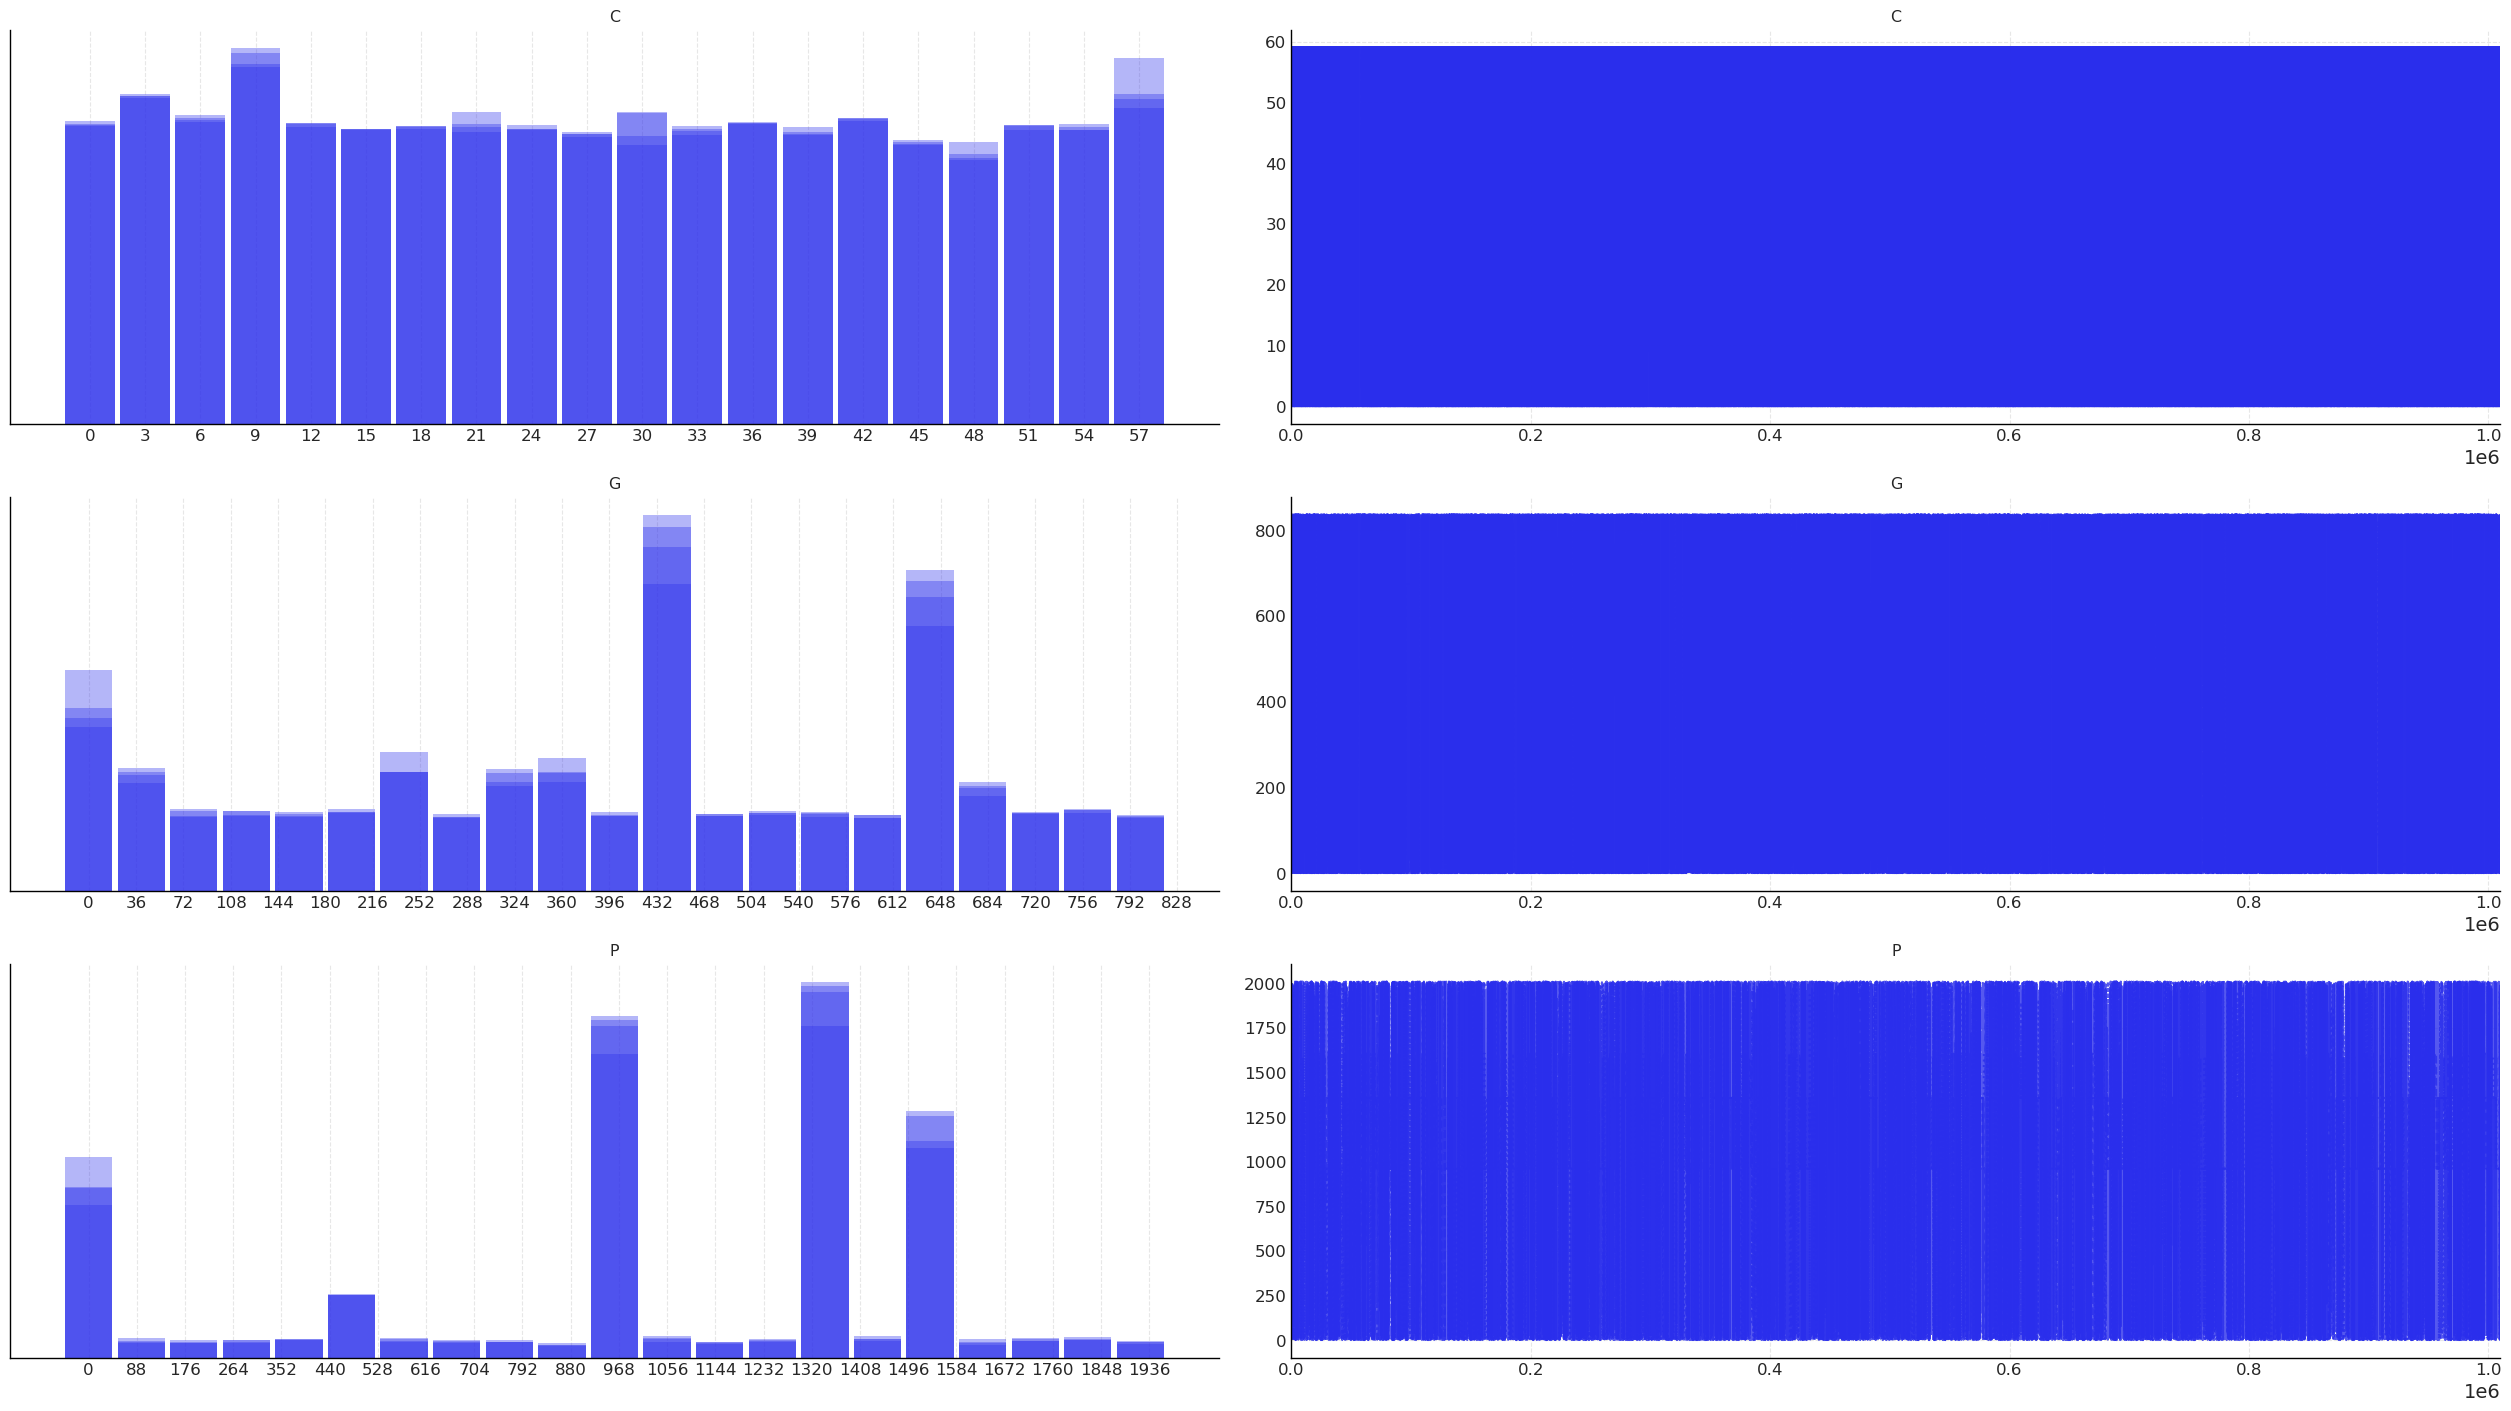

In [248]:
az.style.use("arviz-white")

fig = az.plot_trace(
    trace,
    figsize=(25, 14),  
    combined=False,     
    var_names=None,     
)

for ax in fig.ravel():
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    for line in ax.get_lines():
        line.set_linewidth(1.5)  
        line.set_alpha(0.8)       
        
plt.show()

In [260]:
df = trace.to_dataframe(groups='posterior')

In [250]:
counts = df['C'].value_counts().head(3)
counts

C
11    119509
58     97389
4      84688
Name: count, dtype: int64

In [251]:
def getEffect(effects):
    for effect in effects:
        print(effect.NAME_DRUGBANK[0])

In [252]:
def getCompoundInfo(*compound_indices):
    for rank, compound_index in enumerate(compound_indices, start=1):
        compound = bn_compounds[int(compound_index)]
        print(f"Rank {rank}: {compound.name}")
        print(compound.WIKIPEDIA)
        print(compound.NPASS)
        getEffect(compound.has_effect)
        print()


In [254]:
getCompoundInfo(*counts.index[:3])


Compound 1
['Resveratrol']
['NPC161571']
 adverse effects 
 jaw osteonecrosis and anti-angiogenesis 
 bleeding 
 hemorrhage 
 bleeding and hemorrhage 
 bleeding and thrombocytopenia 
 
Compound 2
['Genistein']
['NPC39426']
 methemoglobinemia 
 adverse effects 
 Thrombosis 
 
Compound 3
['Quercetin']
['NPC20791']
 adverse effects 


The saved top counts identify Resveratrol (`NPC161571`), Genistein (`NPC39426`) and Quercetin (`NPC20791`). They were sampled against `DISEASE_13735`, whose stored UMLS field is `C0011860;C1852091;C4017238`. The original Adult T-cell Leukemia-Lymphoma heading was incorrect.

I treat these counts as outcomes of the specified graph model. Their interpretation needs identifier validation, reproducible category ordering and independent evidence; the saved ranking does not establish treatment for type 2 diabetes.


#### Colorectal cancer — `DISEASE_13720`


In [255]:
for d in bn_diseases:
    if d.name == 'DISEASE_13720':
        d_index = bn_diseases.index(d)
        print(d.UMLS)

['C0007102;C0009402']


In [256]:
# Expensive original sampling request: one million draws per chain.
with mc.Model() as model:
    C = mc.Categorical('C', PC)
    PG = pt.take(PG_C, C, axis=1)
    G = mc.Categorical('G', PG)
    PP_G = pt.take(PP_GC, C, axis=2)
    PP = pt.take(PP_G, G, axis=1)
    P = mc.Categorical('P', PP)
    PD = pt.take(PD_P, P, axis=1)
    D = mc.Categorical('D', PD, observed=d_index)
    trace = mc.sample(1000000, tune=10000, random_seed=SEED, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, G, P]


Output()

Sampling 4 chains for 0 tune and 1_010_000 draw iterations (0 + 4_040_000 draws total) took 224 seconds.


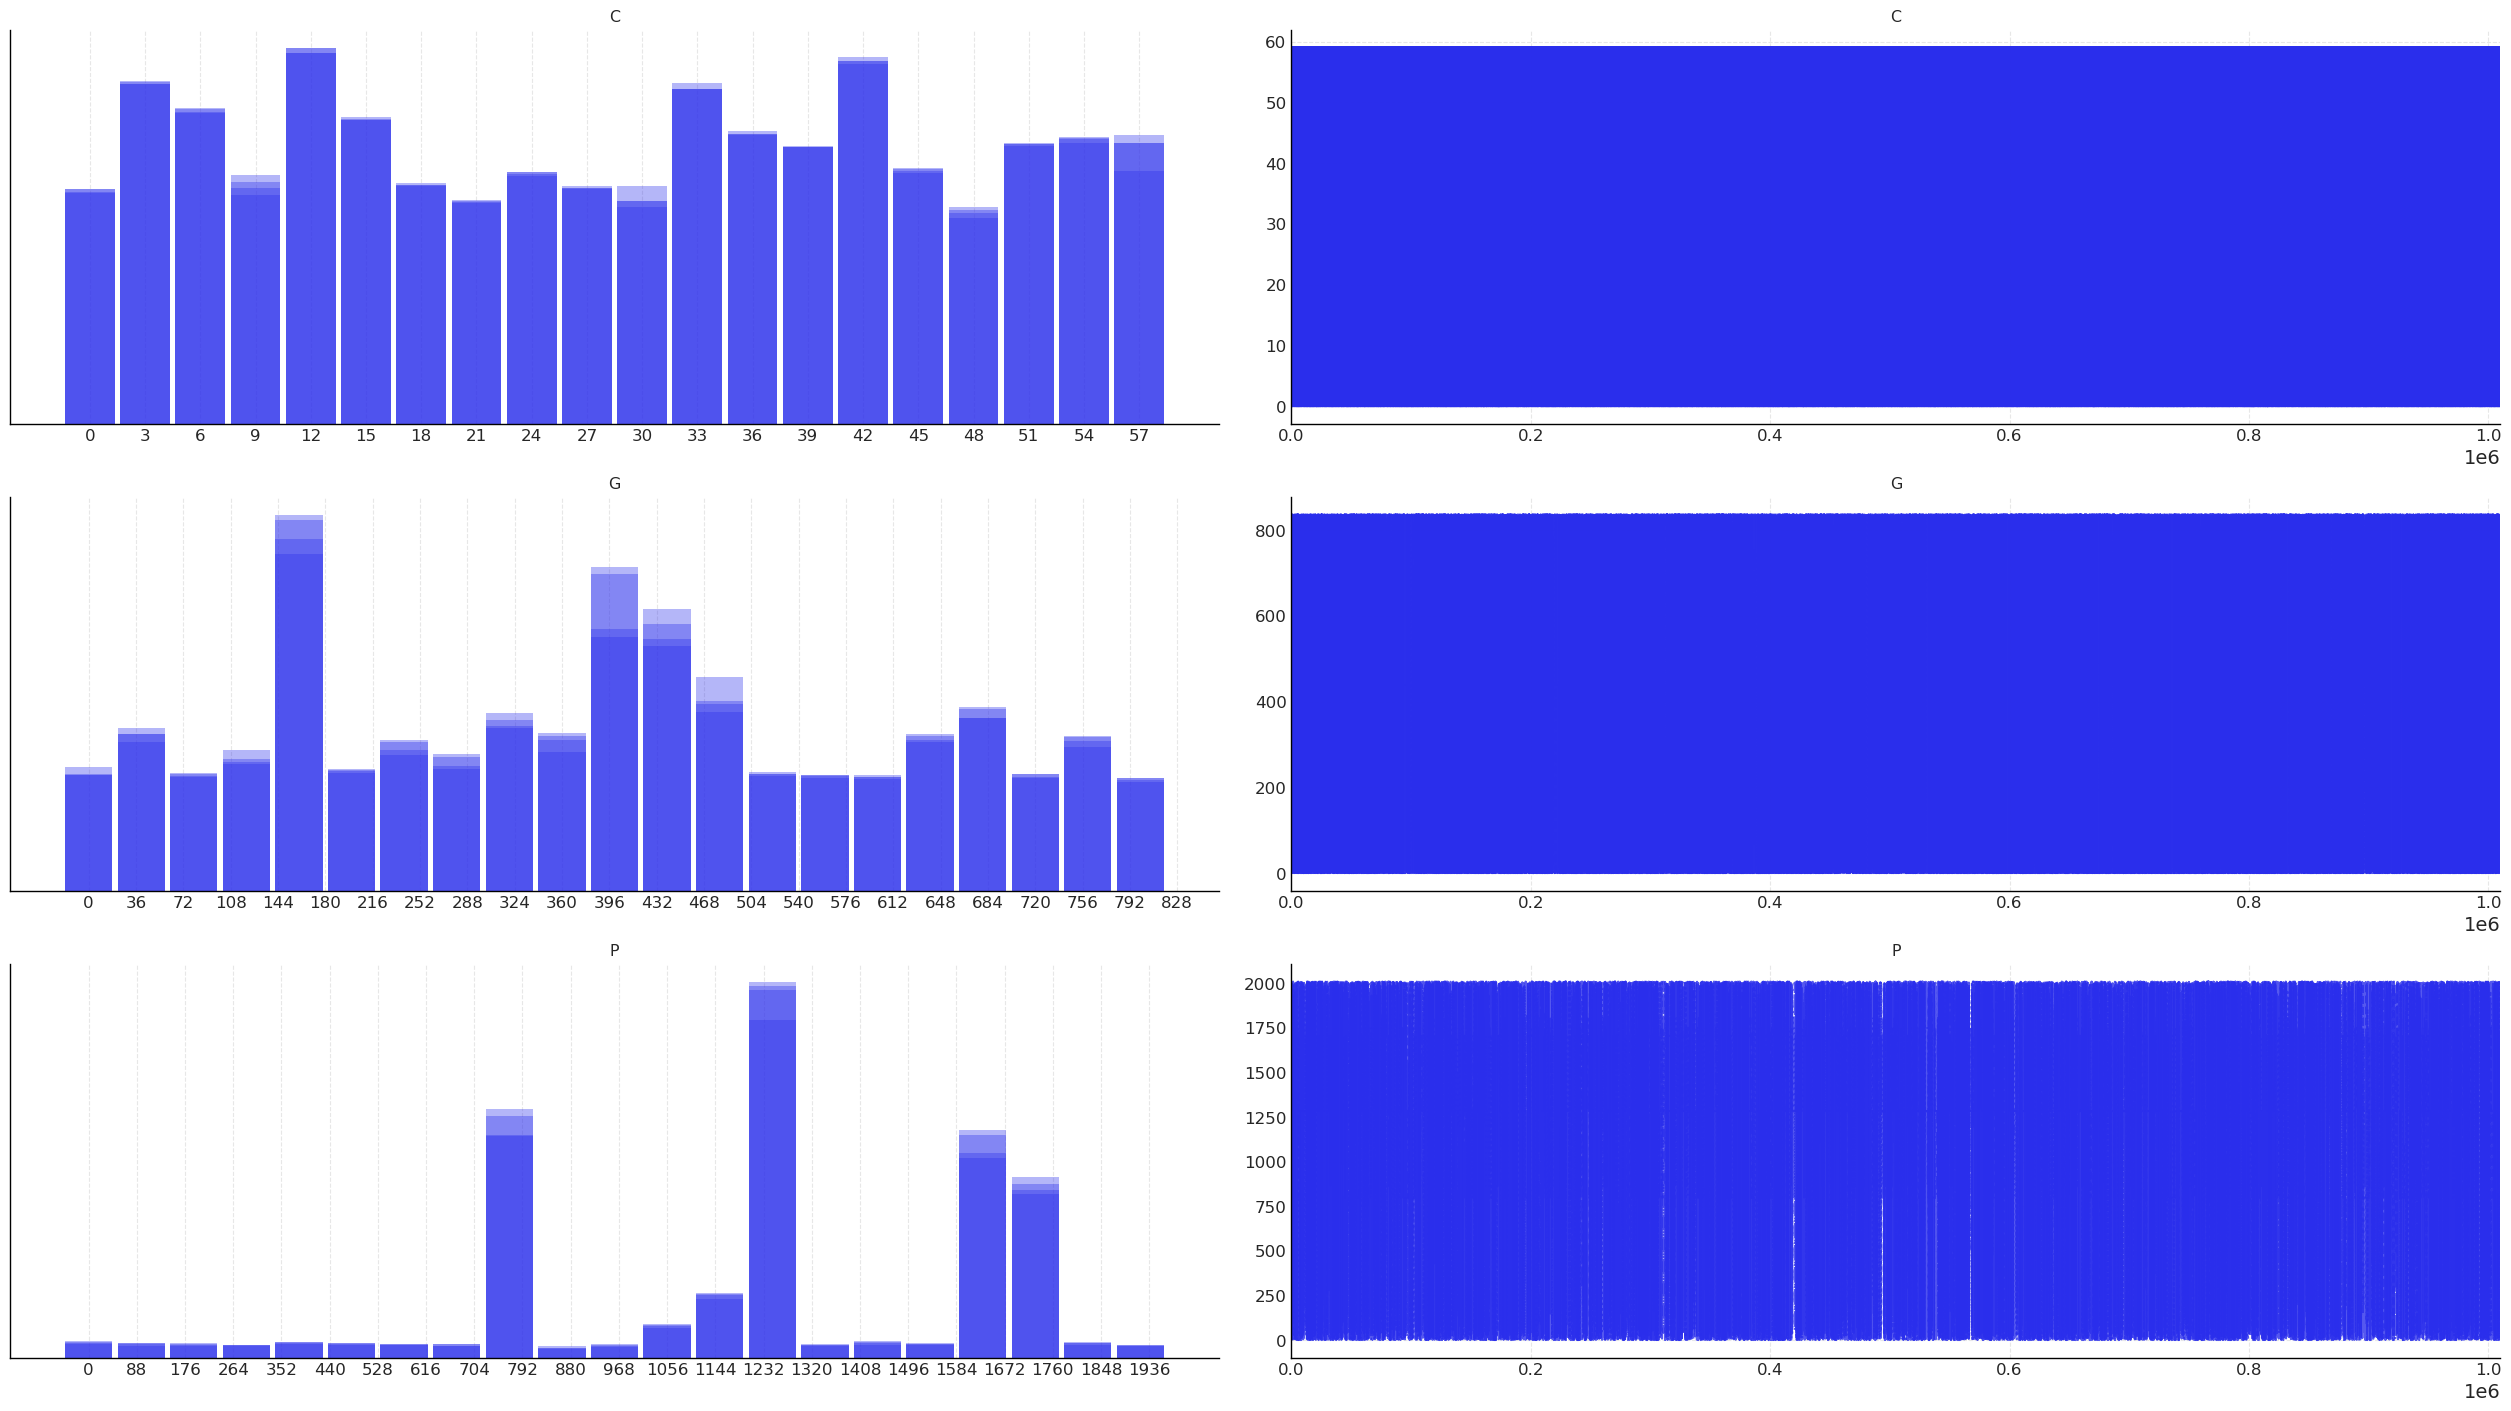

In [257]:
az.style.use("arviz-white")

fig = az.plot_trace(
    trace,
    figsize=(25, 14),  
    combined=False,     
    var_names=None,     
)

for ax in fig.ravel():
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    for line in ax.get_lines():
        line.set_linewidth(1.5)  
        line.set_alpha(0.8)       
        
plt.show()

In [258]:
df = trace.to_dataframe(groups='posterior')
counts = df['C'].value_counts().head(3)
counts

C
35    95616
51    92560
5     92471
Name: count, dtype: int64

In [259]:
getCompoundInfo(*counts.index[:3])


Compound 1
[0]
['NPC136002']
 
Compound 2
[0]
['NPC482689']
 
Compound 3
[0]
['NPC480173']


The saved top categories correspond to `NPC136002`, `NPC482689` and `NPC480173`. Their displayed compound-name fields are missing, so I retain their identifiers rather than the drug names guessed in the original discussion. The observed disease field is `C0007102;C0009402`. The ranking is an exploratory model result and does not establish an approved or effective treatment.


#### Retinitis pigmentosa — `DISEASE_2810`


In [262]:
for d in bn_diseases:
    if d.name == 'DISEASE_2810':
        d_index = bn_diseases.index(d)
        print(d.UMLS)

['C0035334']


In [263]:
# Expensive original sampling request: one million draws per chain.
with mc.Model() as model:
    C = mc.Categorical('C', PC)
    PG = pt.take(PG_C, C, axis=1)
    G = mc.Categorical('G', PG)
    PP_G = pt.take(PP_GC, C, axis=2)
    PP = pt.take(PP_G, G, axis=1)
    P = mc.Categorical('P', PP)
    PD = pt.take(PD_P, P, axis=1)
    D = mc.Categorical('D', PD, observed=d_index)
    trace = mc.sample(1000000, tune=10000, random_seed=SEED, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, G, P]


Output()

Sampling 4 chains for 0 tune and 1_010_000 draw iterations (0 + 4_040_000 draws total) took 220 seconds.


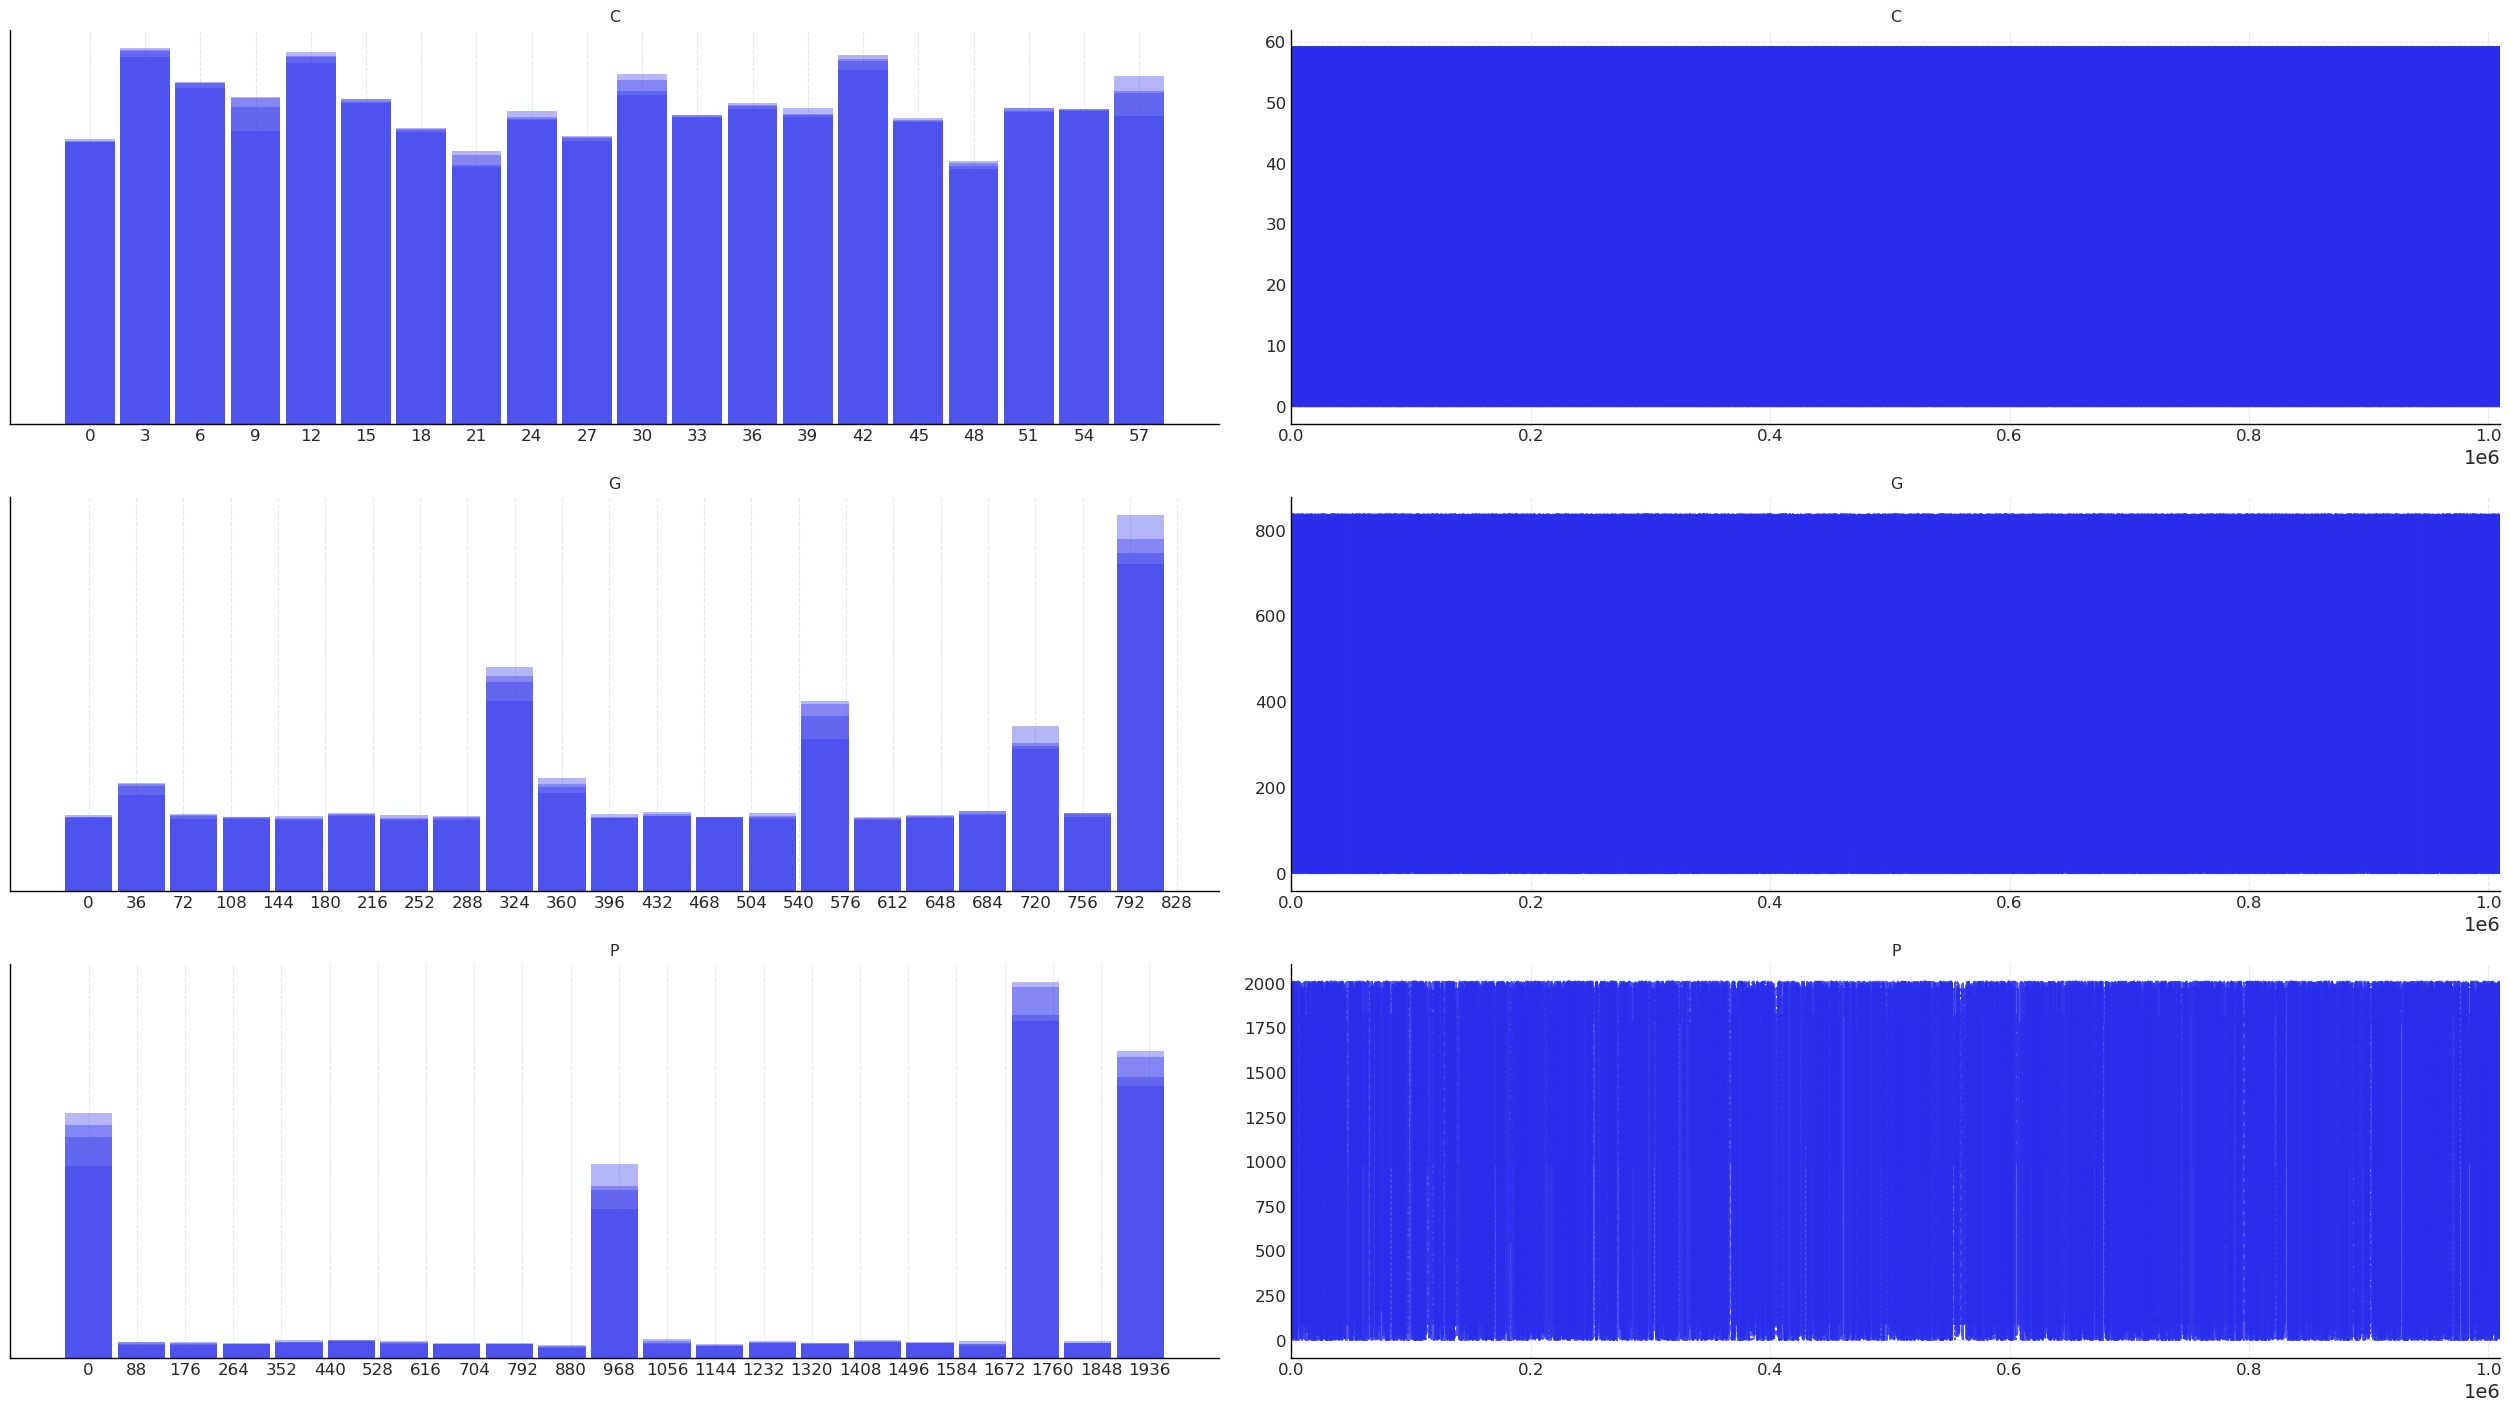

In [264]:
az.style.use("arviz-white")

fig = az.plot_trace(
    trace,
    figsize=(25, 14),  
    combined=False,     
    var_names=None,     
)

for ax in fig.ravel():
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    for line in ax.get_lines():
        line.set_linewidth(1.5)  
        line.set_alpha(0.8)       
        
plt.show()

In [265]:
df = trace.to_dataframe(groups='posterior')
counts = df['C'].value_counts().head(3)
counts

C
11    92089
31    90864
51    81386
Name: count, dtype: int64

In [267]:
getCompoundInfo(*counts.index[:3])


Compound 1
['Resveratrol']
['NPC161571']
 adverse effects 
 jaw osteonecrosis and anti-angiogenesis 
 bleeding 
 hemorrhage 
 bleeding and hemorrhage 
 bleeding and thrombocytopenia 
 
Compound 2
[0]
['NPC109083']
 
Compound 3
[0]
['NPC482689']


The saved top categories correspond to Resveratrol (`NPC161571`), `NPC109083` and `NPC482689`. The observed disease code is `C0035334`; the original Sarcoidosis heading was incorrect. I keep unnamed compounds as identifiers and make no clinical conclusion from their presence in the ranking.


#### Amyotrophic lateral sclerosis — `DISEASE_160`


In [268]:
for d in bn_diseases:
    if d.name == 'DISEASE_160':
        d_index = bn_diseases.index(d)
        print(d.UMLS)

['C0002736']


In [269]:
# Expensive original sampling request: one million draws per chain.
with mc.Model() as model:
    C = mc.Categorical('C', PC)
    PG = pt.take(PG_C, C, axis=1)
    G = mc.Categorical('G', PG)
    PP_G = pt.take(PP_GC, C, axis=2)
    PP = pt.take(PP_G, G, axis=1)
    P = mc.Categorical('P', PP)
    PD = pt.take(PD_P, P, axis=1)
    D = mc.Categorical('D', PD, observed=d_index)
    trace = mc.sample(1000000, tune=10000, random_seed=SEED, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, G, P]


Output()

Sampling 4 chains for 0 tune and 1_010_000 draw iterations (0 + 4_040_000 draws total) took 223 seconds.


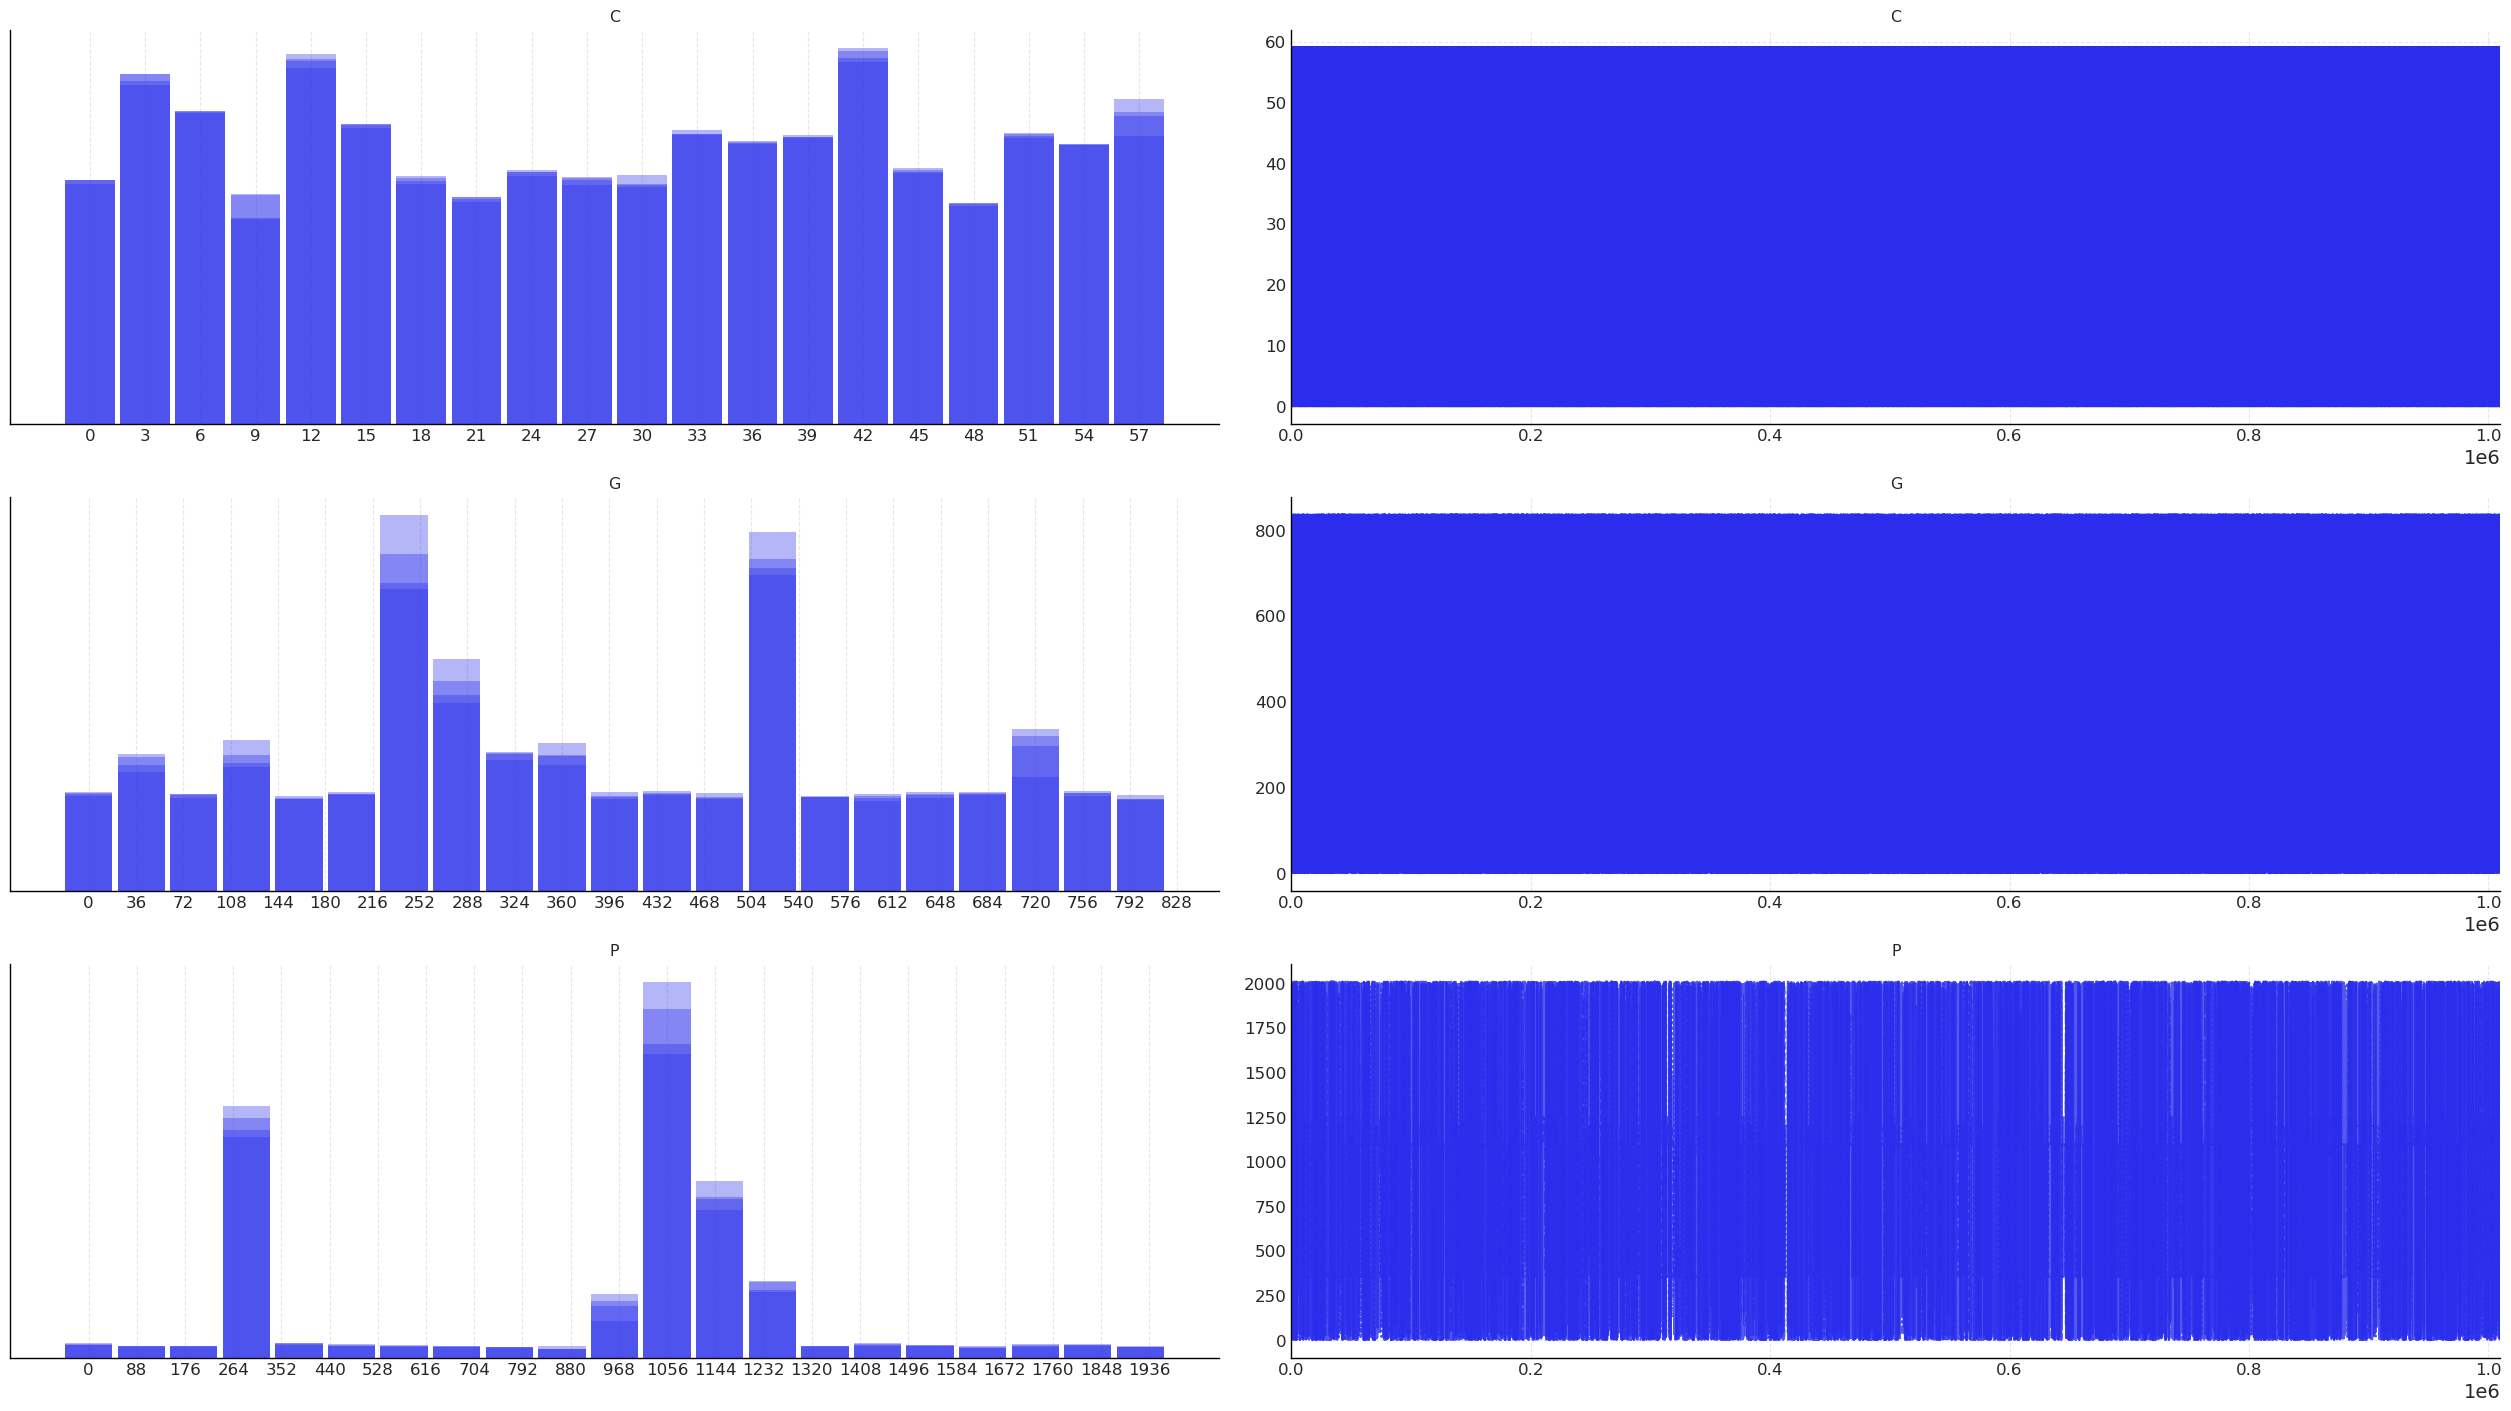

In [270]:
az.style.use("arviz-white")

fig = az.plot_trace(
    trace,
    figsize=(25, 14),  
    combined=False,     
    var_names=None,     
)

for ax in fig.ravel():
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    for line in ax.get_lines():
        line.set_linewidth(1.5)  
        line.set_alpha(0.8)       
        
plt.show()

In [271]:
df = trace.to_dataframe(groups='posterior')
counts = df['C'].value_counts().head(3)
counts

C
5     94660
51    94408
39    94214
Name: count, dtype: int64

In [272]:
getCompoundInfo(*counts.index[:3])


Compound 1
[0]
['NPC480173']
 
Compound 2
[0]
['NPC471579']
 
Compound 3
[0]
['NPC482689']


The saved ranked category order is `5`, `51`, `39`: `NPC480173`, `NPC482689`, `NPC471579`. The original information-printing call used `5`, `39`, `51`, so it reversed the second and third records. The public code now prints information directly from the current ranked indices.

The disease's stored UMLS code is `C0002736`; the original Aortic Stenosis heading was incorrect. None of these unlabeled compound records is assigned a guessed drug identity here.


#### Breast cancer — `DISEASE_7426`


In [277]:
for d in bn_diseases:
    if d.name == 'DISEASE_7426':
        d_index = bn_diseases.index(d)
        print(d.UMLS)

['C0346153;C0006142;C1861906']


In [278]:
# Expensive original sampling request: one million draws per chain.
with mc.Model() as model:
    C = mc.Categorical('C', PC)
    PG = pt.take(PG_C, C, axis=1)
    G = mc.Categorical('G', PG)
    PP_G = pt.take(PP_GC, C, axis=2)
    PP = pt.take(PP_G, G, axis=1)
    P = mc.Categorical('P', PP)
    PD = pt.take(PD_P, P, axis=1)
    D = mc.Categorical('D', PD, observed=d_index)
    trace = mc.sample(1000000, tune=10000, random_seed=SEED, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, G, P]


Output()

Sampling 4 chains for 0 tune and 1_010_000 draw iterations (0 + 4_040_000 draws total) took 268 seconds.


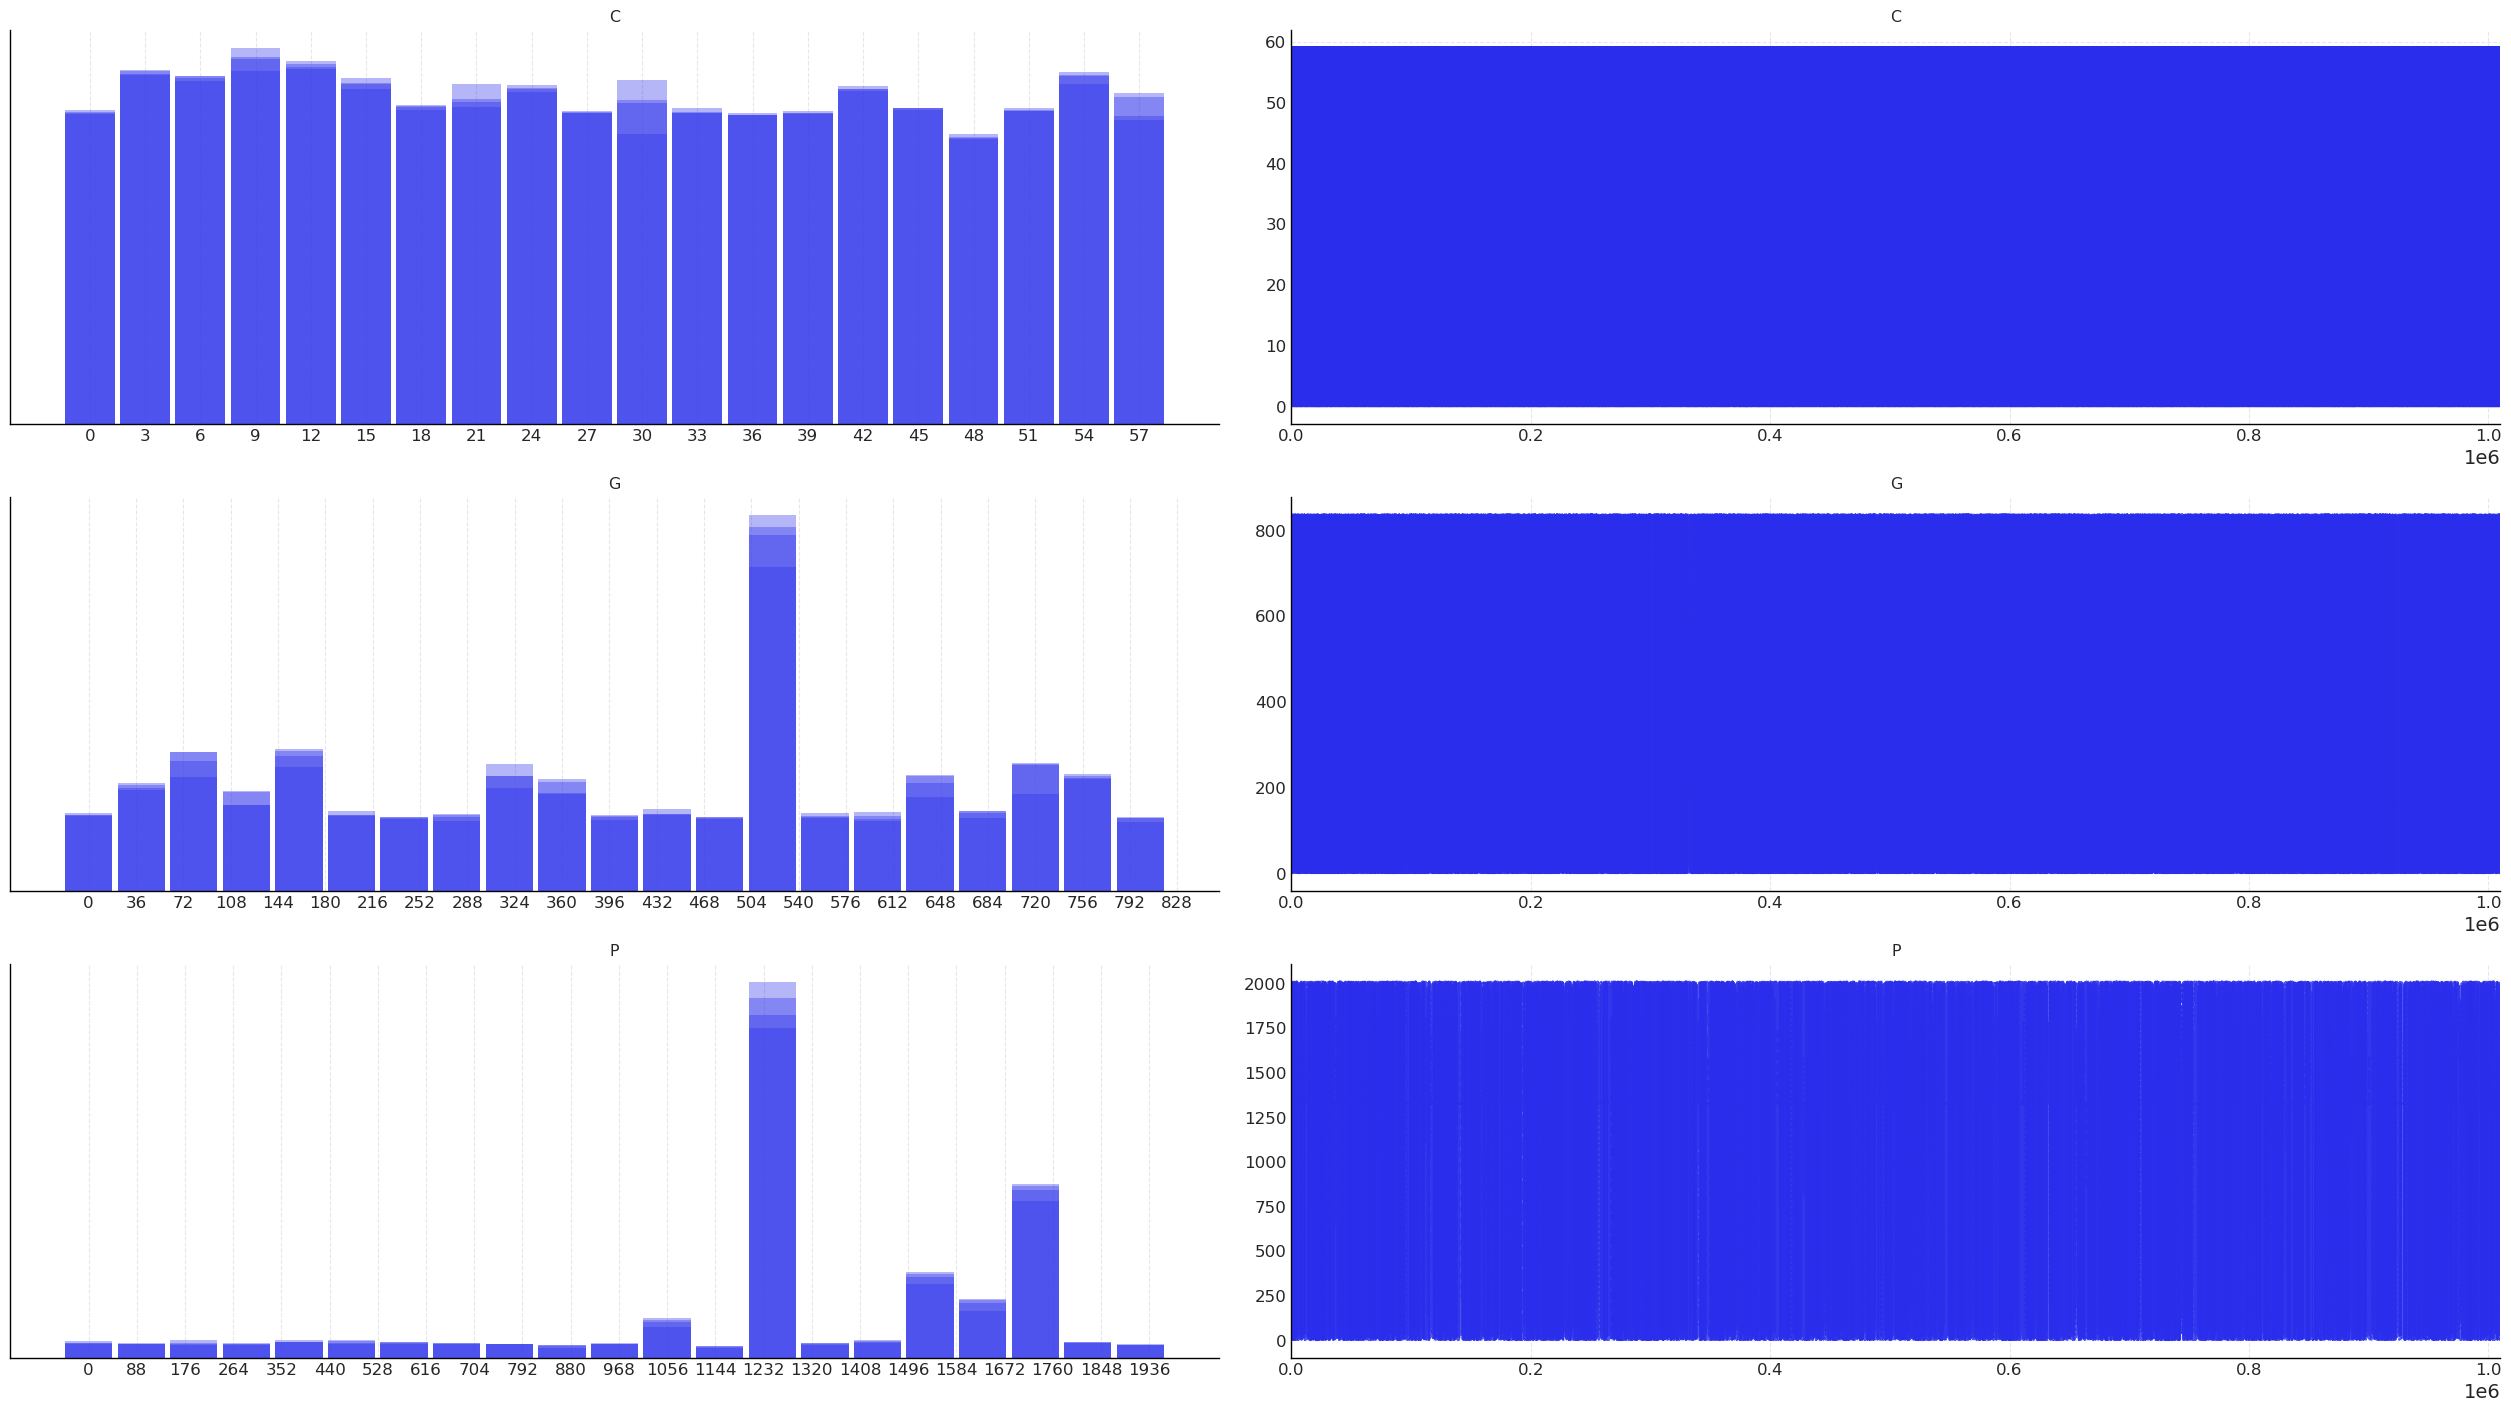

In [279]:
az.style.use("arviz-white")

fig = az.plot_trace(
    trace,
    figsize=(25, 14),  
    combined=False,     
    var_names=None,     
)

for ax in fig.ravel():
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    for line in ax.get_lines():
        line.set_linewidth(1.5)  
        line.set_alpha(0.8)       
        
plt.show()

In [280]:
df = trace.to_dataframe(groups='posterior')
counts = df['C'].value_counts().head(3)
counts

C
11    109417
12     88130
56     86877
Name: count, dtype: int64

In [281]:
getCompoundInfo(*counts.index[:3])


Compound 1
['Resveratrol']
['NPC161571']
 adverse effects 
 jaw osteonecrosis and anti-angiogenesis 
 bleeding 
 hemorrhage 
 bleeding and hemorrhage 
 bleeding and thrombocytopenia 
 
Compound 2
[0]
['NPC32373']
 
Compound 3
[0]
['NPC485883']


The saved top categories correspond to Resveratrol (`NPC161571`), `NPC32373` and `NPC485883`. The observed disease's UMLS field is `C0346153;C0006142;C1861906`; the original COPD heading was incorrect. The ranking does not support the original disease-specific treatment discussion. I retain the counts as historical model results and leave the unnamed compounds unresolved.


## Reflections and limits of the study

I learned that a graph can support several different questions: how the data is organized, where explicit links are missing, and how an assumed probability model ranks connected entities. The three identifier-matched paths provide a concrete graph-completeness finding. The Bayesian stage shows a modeling process, but its rankings depend on hand-set weights and on restricting the graph to high-degree compounds.

I would next validate the OWL schema, audit distinct-node coverage, resolve compound and disease identifiers, compare weights in a sensitivity analysis, and report numerical convergence diagnostics. The saved trace plots alone are insufficient to verify convergence. Missing graph links should not be interpreted as biological absence, and candidate rankings require independent biomedical evaluation.

## AI disclosure

In the original work, I used AI to help with SPARQL queries, grammar and vocabulary, and understanding biomedical concepts. In the second assessment, disease and compound interpretations were sourced using Gemini. The identifier audit found errors in those interpretations, which this public edition now identifies and corrects.

In 2026, I used Codex for editorial packaging: combining the two notebooks, organizing the explanation, checking identifiers against the retained ontology and public references, creating presentation assets, and making paths and display code portable. The original analysis has not been rerun, and this assistance does not independently validate the model or its clinical interpretation.

## References and original background reading

[1] Boudin, M., Diallo, G., Drancé, M. et al. (2023). *The OREGANO knowledge graph for computational drug repurposing*. Scientific Data, 10, 871. https://doi.org/10.1038/s41597-023-02757-0

Disease identifier checks, performed on 4 October 2026:

- NCBI MedGen. *Type 2 diabetes mellitus*, concept `C0011860`. https://www.ncbi.nlm.nih.gov/medgen/41523
- NCBI MedGen. *Colorectal carcinoma*, concept `C0009402`. https://www.ncbi.nlm.nih.gov/medgen/3170
- NCBI MedGen. *Retinitis pigmentosa*, concept `C0035334`. https://www.ncbi.nlm.nih.gov/medgen/20551
- NCBI MedGen. *Amyotrophic lateral sclerosis*, concept `C0002736`. https://www.ncbi.nlm.nih.gov/medgen/274
- NCBI MedGen. *Malignant tumor of breast*, concept `C0006142`. https://www.ncbi.nlm.nih.gov/medgen/651

The following sources were included as background in the original second assessment. They do not validate the numerical weights used in this model, and the original biomedical interpretations should not be inferred from their inclusion.

- Wikipedia contributors. *Proteinopathy*. https://en.wikipedia.org/wiki/Proteinopathy
- Original assessment background link on proteinopathy and disease progression. https://www.mdpi.com/2079-9721/11/1/30
- MedlinePlus Genetics. *How can gene variants affect health and development?* https://medlineplus.gov/genetics/understanding/mutationsanddisorders/mutationscausedisease/
- Wikipedia contributors. *Active site*. https://en.wikipedia.org/wiki/Active_site
- Drouard et al. (2025), original assessment background on protein heritability. https://doi.org/10.1021/acs.jproteome.4c00971
- Encyclopaedia Britannica. *Mechanisms of mutation*. https://www.britannica.com/science/heredity-genetics/Mechanisms-of-mutation
